# Semantic Resume-Job Alignment: Embedding Training & Retrieval Pipeline
## Component 1 of the Semantic Resume Intelligence System

This Google Colab notebook trains and evaluates **Component 1** of the Semantic Resume
Intelligence System: a fine-tuned Sentence Transformer that learns joint representations
of candidate resumes, job descriptions, job titles, and skill profiles, and exposes them
through a small production-style retrieval interface.

### System Architecture Overview
The overall Semantic Resume Intelligence System has two components:
1. **Component 1 (built here)**: a fine-tuned `sentence-transformers/all-mpnet-base-v2`
   model, trained with Multiple Negatives Ranking Loss (MNRL) plus mined hard negatives,
   on positive pairs representing Resume &harr; Job Description, Resume &harr; Role, and
   Resume &harr; Skills alignments.
2. **Component 2 (not built here)**: a lightweight instruction-tuned LLM integrated via
   Retrieval-Augmented Generation (RAG) into a Streamlit application, to turn Component
   1's retrieval scores into human-readable, explainable ATS-style reports.

This notebook builds the full Component 1 pipeline: data loading through a first
production-style retrieval interface (Modules 1-12). It uses the standard
`SentenceTransformer.fit()` training API with `MultipleNegativesRankingLoss`, not a
custom PyTorch training loop.

```mermaid
graph TD
    A[Module 1: Data Loading] --> B[Module 2: Cleaning]
    B --> C[Module 3: Role Processing]
    C --> D[Module 4: MPNet Setup]
    D --> E[Module 5: Text Preparation]
    E --> F[Module 6: Training Pair Generation + Hard Negatives]
    F --> G[Module 7: Retrieval Evaluator + TF-IDF Baseline]
    G --> H[Module 8: MPNet Fine-Tuning]
    H --> I[Module 9: Fine-Tuned Evaluation]
    I --> J[Module 10: Role-Based Evaluation]
    J --> K[Module 11: Embedding Visualization]
    K --> L[Module 12: Production Retrieval]
    L --> M[Module 13+: FAISS, ATS Scoring, Explainability, App]
```

> [!IMPORTANT]
> **Reworked version note:** this notebook fixes a validation-set bug from the original
> version (see Module 7) that made the strict Precision@1 metric measure duplicate-target
> placement rather than retrieval quality, adds TF-IDF and pretrained-model baselines so
> "improvement" has a concrete reference point, adds hard-negative mining, trains for the
> full configured epoch count instead of a hardcoded override, and adds Module 12
> (Production Retrieval).

> [!NOTE]
> **Developer Note on Version Stability**: this notebook pins exact library dependencies
> to guarantee stable runs in a standard Google Colab Free environment.


In [1]:
# ============================================================
# 1. ENVIRONMENT SETUP & DEPENDENCY MANAGEMENT
# ============================================================
# Install pinned, stable packages to avoid dependency conflicts
# in Colab. We do not reinstall torch or numpy to protect environment stability.

!pip install -q \
  sentence-transformers==2.7.0 \
  umap-learn==0.5.6 \
  huggingface-hub==0.23.4 \
  scikit-learn==1.3.2 \
  pandas==2.1.4 \
  numpy==1.26.4 \
  matplotlib==3.8.2 \
  plotly==5.18.0 \
  seaborn==0.13.0

print("Environment setup complete. Libraries installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 44.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Environment setup complete. Libraries installed.


## Setup: Configuration & Reproducibility

Mounts Google Drive, pins global hyperparameters, and seeds every active random number generator (Python `random`, NumPy, PyTorch CPU/GPU) so results are reproducible run to run.


In [2]:
# ============================================================
# 2. CONFIGURATION & REPRODUCIBILITY CONFIG
# ============================================================
import os
import re
import time
import random
import unicodedata
from typing import Dict, List, Tuple, Any, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.amp as amp
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from huggingface_hub import HfApi, login
from sentence_transformers import SentenceTransformer
from google.colab import drive

drive.mount('/content/drive/')
# Global configuration values
MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"
BATCH_SIZE = 16
GRADIENT_ACCUMULATION_STEPS = 2
EPOCHS = 1
LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
MAX_SEQ_LENGTH = 256
DATA_DIR = "/content/drive/MyDrive/SemanticResumeATS/"
MODEL_OUTPUT_DIR = os.path.join(DATA_DIR, "trained_model")
SEED = 42

def seed_everything(seed: int = 42) -> None:
    """
    Sets seeds across Python random, numpy, and PyTorch for deterministic output.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

# GPU detection and VRAM configurations
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Target Execution Device: {device}")
if device.type == "cuda":
    print(f"GPU Model Name: {torch.cuda.get_device_name(0)}")
    print(f"Available GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

Mounted at /content/drive/
Target Execution Device: cuda
GPU Model Name: Tesla T4
Available GPU Memory: 14.56 GB


## Module 1: Data Loading

Mounts the same Google Drive dataset paths as before and loads three sources:
- **Resumes** from `RESUME_DIR` (CSV or `source:::keywords:::resume_text` TXT format)
- **Jobs** from the fixed path `.../datasets/jobs/job_descriptions.csv`
- **ESCO occupation/skill knowledge base**, tried live from the Hugging Face Hub first, falling back to a built-in 150+ occupation dictionary if unreachable

Paths are unchanged from the original notebook.


In [3]:
# ============================================================
# 3. DATA LOADING & DATASET MANAGEMENT
# ============================================================

import os
import glob
import pandas as pd
from datasets import load_dataset

# ------------------------------------------------------------
# Google Drive Paths
# ------------------------------------------------------------

DATA_DIR = "/content/drive/MyDrive/SemanticResumeATS"

RESUME_DIR = os.path.join(DATA_DIR, "datasets", "resumes")
JOB_DIR = os.path.join(DATA_DIR, "datasets", "jobs")

In [4]:
# ------------------------------------------------------------
# Helper Functions
# ------------------------------------------------------------

def find_file(folder, extensions):
    """
    Returns the first file with the given extension.
    """
    for ext in extensions:
        files = glob.glob(os.path.join(folder, ext))
        if len(files):
            return files[0]
    return None

In [5]:
def load_resume_dataset():

    print("="*60)
    print("Loading Resume Dataset...")
    print("="*60)

    txt_file = find_file(RESUME_DIR, ["*.txt"])
    csv_file = find_file(RESUME_DIR, ["*.csv"])

    # ----------------------------------------------------
    # CSV
    # ----------------------------------------------------

    if csv_file is not None:
        resume_df = pd.read_csv(csv_file)
        print("Resume CSV Loaded")
        print(resume_df.shape)
        return resume_df

    # ----------------------------------------------------
    # TXT Resume Corpus
    # ----------------------------------------------------

    elif txt_file is not None:
        resumes = []
        with open(txt_file, "r", encoding="utf-8", errors="ignore") as f:
            for line in f:
                line = line.strip()

                if len(line) < 50:
                    continue

                parts = line.split(":::")

                if len(parts) != 3:
                    continue

                source = parts[0]
                keywords = parts[1]
                resume_text = parts[2]
                resumes.append({"source": source, "keywords": keywords, "resume_text": resume_text})

        resume_df = pd.DataFrame(resumes)
        print("Resume TXT Loaded")
        print(resume_df.shape)
        return resume_df

    else:

        raise FileNotFoundError(f"Resume dataset not found inside:\n{RESUME_DIR}")

In [7]:
# ============================================================
# LOAD JOB DATASET
# ============================================================

print("="*60)
print("Loading Job Dataset...")
print("="*60)

job_path="/content/drive/MyDrive/SemanticResumeATS/datasets/jobs/job_descriptions.csv"
job_df=pd.read_csv(job_path)
print("Original shape:",job_df.shape)
print("\nColumns:")
print(job_df.columns)
job_df=job_df.rename(columns={"Job Title":"job_title", "Job Description":"job_description"})

job_df=job_df.drop_duplicates()
job_df=job_df.dropna(subset=["job_title","job_description"])
job_df=job_df.reset_index(drop=True)
print("\nFinal shape:",job_df.shape)

Loading Job Dataset...
Original shape: (1615940, 23)

Columns:
Index(['Job Id', 'Experience', 'Qualifications', 'Salary Range', 'location',
       'Country', 'latitude', 'longitude', 'Work Type', 'Company Size',
       'Job Posting Date', 'Preference', 'Contact Person', 'Contact',
       'Job Title', 'Role', 'Job Portal', 'Job Description', 'Benefits',
       'skills', 'Responsibilities', 'Company', 'Company Profile'],
      dtype='object')

Final shape: (1615940, 23)


In [8]:
# ============================================================
# ESCO KNOWLEDGE BASE
# ============================================================

from datasets import load_dataset
def build_esco_knowledge_base():

    print("="*60)
    print("Building ESCO Knowledge Base...")
    print("="*60)

    datasets_to_try = ["jjzha/esco", "mw4/esco-skills", "TechWolf/ESCO-Skills"]

    for ds in datasets_to_try:
        try:
            print(f"Trying HuggingFace dataset : {ds}")
            data = load_dataset(ds)
            print(f"Successfully loaded {ds}")
            return data

        except Exception:
            pass

    print("No online ESCO dataset found.")
    print("Loading built-in ESCO knowledge base...")

    esco = {
        "python developer":{
            "skills":["python","django","flask","fastapi","sql","postgresql","git","docker","linux","rest api"]},

        "java developer":{
            "skills":["java","spring","spring boot","hibernate","mysql","docker","git","maven","microservices"]},

        ".net developer":{
            "skills":["c#",".net","asp.net","entity framework","sql server","azure","git"]},

        "frontend developer":{
            "skills":["html","css","javascript","react","angular","vue","typescript","git"]},

        "backend developer":{
            "skills":["python","java","node.js","sql","docker","kubernetes","redis","rest api"]},

        "full stack developer":{
            "skills":["html","css","javascript","react","node.js","python","sql","docker","git"]},

        "software engineer":{
            "skills":["python","java","c++","git","oop","algorithms","data structures","linux"]},

        "software developer":{
            "skills":["python","java","c#","sql","git","docker","rest api"]},

        "web developer":{
            "skills":["html","css","javascript","react","node.js","bootstrap","git"]},

        "mobile application developer":{
            "skills":["flutter","dart","android","ios","firebase","git"]},

        "android developer":{
            "skills":["java","kotlin","android sdk","firebase","xml","git"]},

        "ios developer":{
            "skills":["swift","swiftui","xcode","ios sdk","git"]},

        "react developer":{
            "skills":["react","javascript","redux","html","css","typescript"]},

        "angular developer":{
            "skills":["angular","typescript","rxjs","html","css"]},

        "vue developer":{
            "skills":["vue","javascript","vuex","html","css"]},

        "node.js developer":{
            "skills":["node.js","express","mongodb","jwt","rest api","docker"]},

        "php developer":{
            "skills":["php","laravel","mysql","apache","rest api"]},

        "laravel developer":{
            "skills":["php","laravel","mysql","redis","docker"]},

        "wordpress developer":{
            "skills":["wordpress","php","mysql","css","javascript"]},

        "devops engineer":{
            "skills":["docker","kubernetes","terraform","jenkins","linux","aws","bash","ci/cd"]},

        "site reliability engineer":{
            "skills":["linux","docker","kubernetes","terraform","prometheus","grafana","aws"]},

        "cloud engineer":{
            "skills":["aws","azure","gcp","docker","terraform","linux","networking"]},

        "cloud architect":{
            "skills":["aws","azure","gcp","terraform","kubernetes","security","architecture"]},

        "aws engineer":{
            "skills":["aws","ec2","lambda","s3","iam","cloudformation"]},

        "azure engineer":{
            "skills":["azure","azure devops","aks","azure functions","terraform"]},

        "data scientist":{
            "skills":["python","pandas","numpy","statistics","machine learning","sql","matplotlib","scikit-learn"]},

        "data analyst":{
            "skills":["sql","excel","power bi","tableau","python","statistics","pandas"]},

        "business analyst":{
            "skills":["sql","excel","power bi","requirements gathering","jira","agile"]},

        "business intelligence developer":{
            "skills":["power bi","tableau","sql","data warehouse","etl"]},

        "data engineer":{
            "skills":["python","sql","spark","hadoop","airflow","etl","snowflake"]},

        "machine learning engineer":{
            "skills":["python","tensorflow","pytorch","scikit-learn","docker","mlops","aws"]},

        "deep learning engineer":{
            "skills":["tensorflow","keras","pytorch","cnn","rnn","transformers","gpu"]},

        "computer vision engineer":{
            "skills":["opencv","python","cnn","yolo","tensorflow","pytorch"]},

        "nlp engineer":{
            "skills":["python","transformers","bert","huggingface","spacy","nltk","llm"]},

        "ai engineer":{
            "skills":["python","llm","rag","langchain","vector database","transformers","huggingface"]},

        "prompt engineer":{
            "skills":["prompt engineering","llm","openai","gemini","claude","rag"]},

        "mlops engineer":{
            "skills":["mlflow","docker","kubernetes","airflow","aws","python","git"]},

        "research scientist":{
            "skills":["python","deep learning","statistics","research","transformers","pytorch"]},

        "database administrator":{
            "skills":["sql","oracle","mysql","postgresql","backup","replication","performance tuning"]},

        "sql developer":{
            "skills":["sql","stored procedures","triggers","mysql","postgresql","sql server"]},

        "mongodb developer":{
            "skills":["mongodb","nosql","aggregation","replication","node.js"]},

        "oracle developer":{
            "skills":["oracle","pl/sql","sql","database design"]},

        "cyber security analyst":{
            "skills":["network security","wireshark","siem","firewall","incident response","owasp"]},

        "penetration tester":{
            "skills":["kali linux","metasploit","burp suite","owasp","python"]},

        "security engineer":{
            "skills":["iam","siem","network security","linux","aws","azure"]},

        "network engineer":{
            "skills":["tcp/ip","routing","switching","firewall","cisco","vpn"]},

        "system administrator":{
            "skills":["linux","windows server","active directory","bash","powershell"]},

        "embedded engineer":{
            "skills":["c","c++","embedded systems","microcontrollers","rtos","arm"]},

        "robotics engineer":{
            "skills":["ros","python","c++","opencv","robotics","slam"]},

        "iot engineer":{
            "skills":["mqtt","arduino","raspberry pi","embedded c","python"]},

        "blockchain developer":{
            "skills":["solidity","ethereum","smart contracts","web3","javascript"]},

        "game developer":{
            "skills":["unity","unreal engine","c#","c++","game physics"]},

        "qa engineer":{
            "skills":["selenium","manual testing","automation","jira","testng"]},

        "test automation engineer":{
            "skills":["selenium","python","java","cypress","playwright"]},

        "ui ux designer":{
            "skills":["figma","adobe xd","wireframing","prototyping","user research"]},

        "product manager":{
            "skills":["agile","scrum","jira","roadmap","stakeholder management"]},

        "technical product manager":{
            "skills":["agile","scrum","sql","analytics","roadmap","jira"]},

        "project manager":{
            "skills":["agile","scrum","jira","risk management","planning"]},

        "scrum master":{
            "skills":["scrum","agile","jira","facilitation","sprint planning"]},

        "salesforce developer":{
            "skills":["salesforce","apex","lightning","soql","crm"]},

        "sap consultant":{
            "skills":["sap","abap","hana","erp","business process"]},

        "etl developer":{
            "skills":["etl","ssis","informatica","sql","data warehouse"]},

        "big data engineer":{
            "skills":["spark","hadoop","kafka","hive","scala","python"]},

        "data warehouse engineer":{
            "skills":["snowflake","redshift","bigquery","sql","etl"]},

        "linux administrator":{
            "skills":["linux","bash","shell scripting","systemd","networking"]},

        "windows administrator":{
            "skills":["windows server","active directory","powershell","dns","dhcp"]},

        "ethical hacker":{"skills":["kali linux","metasploit","burp suite","owasp","nmap","wireshark","python"]},

        "security analyst":{"skills":["siem","splunk","firewall","wireshark","incident response","network security"]},

        "soc analyst":{"skills":["splunk","siem","threat intelligence","incident response","linux","firewall"]},

        "cloud security engineer":{"skills":["aws","azure","iam","terraform","network security","docker","kubernetes"]},

        "forensics analyst":{"skills":["autopsy","volatility","wireshark","memory analysis","disk forensics","linux"]},

        "data architect":{"skills":["sql","data warehouse","snowflake","etl","data modeling","bigquery"]},

        "data visualization engineer":{"skills":["power bi","tableau","sql","python","matplotlib","analytics"]},

        "gen ai engineer":{"skills":["python","llm","langchain","rag","transformers","huggingface","vector database"]},

        "llm engineer":{"skills":["python","transformers","langchain","rag","prompt engineering","huggingface"]},

        "ai researcher":{"skills":["python","pytorch","tensorflow","transformers","deep learning","statistics"]},

        "prompt engineer":{"skills":["prompt engineering","openai","gemini","claude","rag","langchain"]},

        "rag engineer":{"skills":["langchain","faiss","chroma","vector database","python","llm"]},

        "data annotation specialist":{"skills":["labeling","data cleaning","quality assurance","excel","python"]},

        "seo specialist":{"skills":["seo","google analytics","google ads","content marketing","keyword research"]},

        "digital marketing manager":{"skills":["seo","sem","google analytics","google ads","social media","content marketing","email marketing","marketing automation"]},

        "content writer":{"skills":["copywriting","seo","content marketing","research","editing"]},

        "social media manager":{"skills":["instagram marketing","facebook ads","analytics","content creation","canva"]},

        "hr manager":{"skills":["recruitment","employee engagement","payroll","hrms","communication"]},

        "recruiter":{"skills":["recruitment","linkedin","screening","interviewing","communication"]},

        "financial analyst":{"skills":["excel","financial modeling","sql","power bi","forecasting"]},

        "accountant":{"skills":["tally","excel","bookkeeping","gst","financial reporting"]},

        "operations manager":{"skills":["operations","planning","excel","communication","leadership"]},

        "technical writer":{"skills":["documentation","api documentation","markdown","git","communication"]},

        "support engineer":{"skills":["linux","sql","networking","troubleshooting","customer support"]},

        "system engineer":{"skills":["linux","networking","docker","bash","monitoring"]},

        "database engineer":{"skills":["mysql","postgresql","sql","performance tuning","replication"]},

        "crm developer":{"skills":["salesforce","crm","apex","soql","lightning"]},

        "erp consultant":{"skills":["sap","erp","hana","abap","business process"]},

        "qa analyst":{"skills":["manual testing","selenium","jira","test cases","automation"]},

        "automation engineer":{"skills":["selenium","playwright","python","java","testng"]},

        "gis analyst":{"skills":["arcgis","qgis","python","spatial analysis","geospatial data"]},

        "oracle database administrator":{"skills":["oracle","pl/sql","sql","rman","dataguard","linux","oracle 11g","oracle 12c","performance tuning","backup"]},

        "sql database administrator":{"skills":["sql server","t-sql","ssis","ssrs","stored procedures","database administration","backup","clustering"]},

        "database administrator":{"skills":["sql","oracle","mysql","postgresql","database design","backup","replication","performance tuning"]},

        "database developer":{"skills":["sql","pl/sql","stored procedures","triggers","mysql","postgresql","database design"]},

        "database specialist":{"skills":["sql","oracle","mysql","database administration","backup","performance tuning"]},

        "database engineer":{"skills":["sql","postgresql","mysql","oracle","etl","data modeling","database design"]},

        "etl developer":{"skills":["etl","ssis","informatica","sql","data warehouse","datastage","talend"]},

        "etl engineer":{"skills":["etl","ssis","informatica","airflow","sql","data warehouse","python"]},

        "data warehouse developer":{"skills":["sql","etl","ssis","snowflake","redshift","data warehouse","postgresql"]},

        "data warehouse engineer":{"skills":["snowflake","redshift","bigquery","sql","etl","airflow"]},

        "business intelligence developer":{"skills":["power bi","tableau","sql","ssis","ssrs","data warehouse","etl"]},

        "business intelligence analyst":{"skills":["power bi","tableau","sql","excel","data visualization","analytics"]},

        "report developer":{"skills":["power bi","tableau","ssrs","sql","excel","analytics"]},

        "amazon redshift administrator":{"skills":["redshift","postgresql","sql","aws","etl","data warehouse"]},

        "postgresql administrator":{"skills":["postgresql","sql","backup","replication","performance tuning","linux"]},

        "mysql administrator":{"skills":["mysql","sql","backup","replication","linux","performance tuning"]},

        "mongodb administrator":{"skills":["mongodb","nosql","replication","sharding","backup","linux"]},

        "oracle developer":{"skills":["oracle","pl/sql","sql","forms","reports","database design"]},

        "sql developer":{"skills":["sql","stored procedures","triggers","views","functions","sql server"]},

        "ssis developer":{"skills":["ssis","sql server","etl","data warehouse","stored procedures"]},

        "ssrs developer":{"skills":["ssrs","sql server","reporting","sql","power bi"]},

        "data modeler":{"skills":["data modeling","sql","er diagrams","database design","etl"]},

        "data architect":{"skills":["data modeling","sql","data warehouse","snowflake","aws","etl"]},

        "data governance engineer":{
            "skills":["data governance","sql","data quality","metadata","collibra","python"]},

        "data quality analyst":{
            "skills":["sql","data validation","excel","python","quality assurance","power bi"]},

        "data migration engineer":{
            "skills":["sql","etl","oracle","postgresql","mysql","data migration"]},

        "power bi developer":{
            "skills":["power bi","dax","sql","power query","excel","data modeling"]},

        "tableau developer":{
            "skills":["tableau","sql","data visualization","excel","analytics"]},

        "snowflake developer":{
            "skills":["snowflake","sql","etl","python","data warehouse","airflow"]},

        "bigquery engineer":{
            "skills":["bigquery","sql","gcp","etl","python","data warehouse"]},

        "apache spark developer":{
            "skills":["spark","scala","python","hadoop","sql","kafka"]},

        "kafka engineer":{
            "skills":["kafka","zookeeper","java","spark","stream processing","docker"]},

        "airflow engineer":{
            "skills":["apache airflow","python","sql","etl","docker","data pipeline"]},

        "computer vision researcher":{
            "skills":["opencv","python","cnn","yolo","tensorflow","pytorch","research"]},

        "reinforcement learning engineer":{
            "skills":["python","pytorch","gym","reinforcement learning","deep learning"]},

        "generative ai engineer":{
            "skills":["python","llm","rag","langchain","transformers","huggingface","vector database"]},

        "chatbot developer":{
            "skills":["python","langchain","llm","rag","fastapi","vector database"]},

        "streamlit developer":{
            "skills":["python","streamlit","pandas","plotly","sql","machine learning"]},

        "computer vision developer":{
            "skills":["opencv","python","yolo","tensorflow","pytorch","image processing"]},

        "tensorflow developer":{
            "skills":["tensorflow","keras","python","deep learning","cnn","gpu"]},

        "pytorch developer":{
            "skills":["pytorch","python","deep learning","transformers","cnn"]},

        "data labeling engineer":{
            "skills":["data annotation","python","quality assurance","excel","labeling"]},

        "api developer":{
            "skills":["fastapi","flask","django","rest api","python","jwt"]},

        "microservices developer":{
            "skills":["java","spring boot","docker","kubernetes","microservices","redis"]},

        "golang developer":{
            "skills":["go","grpc","docker","postgresql","microservices"]},

        "rust developer":{
            "skills":["rust","actix","tokio","postgresql","docker"]},

        "c++ developer":{
            "skills":["c++","oop","stl","algorithms","linux","cmake"]},

        "c developer":{
            "skills":["c","pointers","memory management","linux","embedded systems"]},

        "firmware engineer":{
            "skills":["c","c++","embedded systems","rtos","microcontrollers","uart"]},

        "linux kernel engineer":{
            "skills":["linux","c","kernel programming","device drivers","bash"]},

        "network administrator":{
            "skills":["tcp/ip","routing","switching","dns","dhcp","firewall"]},

        "cloud administrator":{
            "skills":["aws","azure","linux","terraform","networking","docker"]},

        "azure architect":{
            "skills":["azure","terraform","kubernetes","network security","architecture"]},

        "aws architect":{
            "skills":["aws","ec2","lambda","terraform","cloudformation","architecture"]},

        "gcp engineer":{
            "skills":["gcp","bigquery","cloud functions","docker","terraform"]},

        "incident responder":{
            "skills":["incident response","siem","splunk","linux","wireshark"]},

        "malware analyst":{
            "skills":["ida pro","ghidra","python","reverse engineering","malware analysis"]},

        "reverse engineer":{
            "skills":["ghidra","ida pro","assembly","c++","reverse engineering"]},

        "vulnerability analyst":{
            "skills":["owasp","burp suite","nmap","wireshark","metasploit"]},

        "seo analyst":{
            "skills":["seo","google analytics","keyword research","content marketing"]},

        "performance marketer":{
            "skills":["google ads","facebook ads","analytics","seo","marketing automation"]},

        "marketing analyst":{
            "skills":["excel","google analytics","power bi","sql","analytics"]},

        "video editor":{
            "skills":["premiere pro","after effects","davinci resolve","video editing"]},

        "graphic designer":{
            "skills":["photoshop","illustrator","figma","canva","branding"]},

        "vfx artist":{
            "skills":["after effects","blender","maya","cinema 4d","compositing"]},

        "ui designer":{
            "skills":["figma","wireframing","prototyping","adobe xd","design systems"]},

        "ux researcher":{
            "skills":["user research","figma","wireframing","prototyping","analytics"]}

        }

    rows = []

    for role,data in esco.items():

      skills=sorted(list(set(data["skills"])))

      rows.append({
          "occupation":role,
          "role":role,
          "skills":skills,
          "skill_string":" ".join(skills)
      })

    esco_df=pd.DataFrame(rows)


    print(f"Built ESCO Knowledge Base with {len(esco_df)} occupations.")

    return esco, esco_df


esco, esco_df = build_esco_knowledge_base()

Building ESCO Knowledge Base...
Trying HuggingFace dataset : jjzha/esco
Trying HuggingFace dataset : mw4/esco-skills
Trying HuggingFace dataset : TechWolf/ESCO-Skills
No online ESCO dataset found.
Loading built-in ESCO knowledge base...
Built ESCO Knowledge Base with 155 occupations.


In [9]:
# ------------------------------------------------------------
# Execute Loading
# ------------------------------------------------------------

resume_df = load_resume_dataset()
print()

print("="*60)
print("SUMMARY")
print("="*60)

print("Resume Dataset :", resume_df.shape)
print("Job Dataset    :", job_df.shape)
print("ESCO Dataset   :", esco_df.shape)

Loading Resume Dataset...
Resume TXT Loaded
(29780, 3)

SUMMARY
Resume Dataset : (29780, 3)
Job Dataset    : (1615940, 23)
ESCO Dataset   : (155, 4)


## Module 2: Cleaning

Text-cleaning primitives (unicode normalization, HTML/URL/email stripping, abbreviation normalization, experience/section extraction, regex skill extraction), applied to the resume and job datasets. Role normalization is handled separately in Module 3, since it depends on the ESCO role vocabulary.


In [10]:
# ============================================================
# MODULE 2: CLEANING
# ============================================================
#
# This module builds the text-cleaning primitives used across the
# rest of the pipeline: unicode normalization, generic text cleaning,
# technical-abbreviation normalization, experience/section extraction,
# and regex-based skill extraction. Role-specific normalization lives
# in Module 3, since it depends on the ESCO role vocabulary.
#
# BUG FIX vs. the original notebook: the previous version defined two
# separate synonym dictionaries (a larger unused `SYNONYM_MAP` and a
# smaller one hardcoded inside `normalize_synonyms`), so half the
# abbreviations were silently never applied. They're merged into one
# canonical map here.
# ============================================================

import html
import unicodedata

print("=" * 60)
print("MODULE 2: CLEANING")
print("=" * 60)

# ============================================================
# UNICODE NORMALIZATION
# ============================================================

def unicode_normalize(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = unicodedata.normalize("NFKC", text)
    return text

# ============================================================
# BASIC TEXT CLEANING
# ============================================================

def clean_text(text):
    if pd.isna(text):
        return ""

    text = unicode_normalize(text)
    text = html.unescape(text)
    text = text.lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"\n", " ", text)
    text = re.sub(r"\t", " ", text)
    text = re.sub(r"[^a-z0-9+#./ ]", " ", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()

# ============================================================
# TECHNICAL SYNONYM NORMALIZATION (single, merged map)
# ============================================================

SYNONYM_MAP = {
    "ml": "machine learning",
    "ai": "artificial intelligence",
    "dl": "deep learning",
    "nlp": "natural language processing",
    "cv": "computer vision",
    "js": "javascript",
    "ts": "typescript",
    "tf": "tensorflow",
    "postgres": "postgresql",
    "mongo": "mongodb",
    "node": "node.js",
    "nodejs": "node.js",
    "py": "python",
    "dotnet": ".net",
    "asp net": "asp.net",
    "restful": "rest api",
    "ci cd": "ci/cd",
    "aws cloud": "aws",
    "azure cloud": "azure",
    "gcp cloud": "gcp",
    "powerbi": "power bi",
    "scikit learn": "scikit-learn",
    "hugging face": "huggingface",
    "pytorch lightning": "pytorch",
}

def normalize_synonyms(text):
    """
    Normalize common abbreviations without corrupting words.
    Uses regex word-boundary matching so e.g. "html" is never
    accidentally matched by the "ts" -> "typescript" rule, etc.
    """
    if pd.isna(text):
        return ""

    text = str(text).lower()

    for old, new in SYNONYM_MAP.items():
        pattern = rf'(?<![a-zA-Z0-9]){re.escape(old)}(?![a-zA-Z0-9])'
        text = re.sub(pattern, new, text)

    return text

# ============================================================
# EXPERIENCE EXTRACTION
# ============================================================

def extract_experience(text):
    if pd.isna(text):
        return None
    text = str(text).lower()

    patterns = [
        r'(\d+)\+?\s*(?:years?|yrs?)\s+of\s+experience',
        r'experience\s*[:\-]?\s*(\d+)\+?\s*(?:years?|yrs?)',
        r'minimum\s+(\d+)\+?\s*(?:years?|yrs?)',
        r'at least\s+(\d+)\+?\s*(?:years?|yrs?)',
        r'over\s+(\d+)\+?\s*(?:years?|yrs?)',
    ]

    for p in patterns:
        m = re.search(p, text)
        if m:
            return int(m.group(1))

    return None

# ============================================================
# SECTION EXTRACTION
# ============================================================

SECTION_HEADERS = {
    "skills": ["skills", "technical skills", "technologies", "core competencies"],
    "education": ["education", "academic", "qualification"],
    "experience": ["experience", "work experience", "employment history"],
    "projects": ["projects", "project experience"],
    "certifications": ["certifications", "certificate"],
    "summary": ["summary", "profile", "objective", "professional summary"],
}

def extract_sections(text):
    if pd.isna(text):
        return {}

    text = str(text)
    sections = {}
    lower = text.lower()
    for section, headers in SECTION_HEADERS.items():
        sections[section] = ""
        for h in headers:
            idx = lower.find(h)
            if idx != -1:
                end = len(text)
                for other_headers in SECTION_HEADERS.values():
                    for other in other_headers:
                        j = lower.find(other, idx + len(h))
                        if j != -1 and j < end:
                            end = j
                sections[section] = text[idx:end].strip()
                break

    return sections

print("Text-cleaning primitives ready.")


MODULE 2: CLEANING
Text-cleaning primitives ready.


In [11]:
# ============================================================
# SKILL VOCABULARY & EXTRACTION
# ============================================================

skill_vocab = set()

for skills in esco_df["skills"]:
    if isinstance(skills, list):
        for skill in skills:
            skill = str(skill).lower().strip()
            if skill:
                skill_vocab.add(skill)

print("Skill vocabulary size :", len(skill_vocab))

def extract_skills(text):
    """
    Extract technical skills using regex word-boundary matching.
    Prevents false matches like:
        c -> architecture
        ios -> comparison
        r -> engineer
    """
    if pd.isna(text):
        return []
    text = str(text).lower()
    found = set()
    for skill in skill_vocab:
        skill = skill.lower().strip()
        pattern = rf'(?<![a-zA-Z0-9]){re.escape(skill)}(?![a-zA-Z0-9])'
        if re.search(pattern, text):
            found.add(skill)
    return sorted(found)

print("Skill extraction function ready.")

# ============================================================
# APPLY CLEANING TO RESUMES
# ============================================================

print()
print("Cleaning resume dataset...")

resumes_clean = resume_df.copy()

if "resume" in resumes_clean.columns:
    resumes_clean = resumes_clean.rename(columns={"resume": "resume_text"})
if "Resume" in resumes_clean.columns:
    resumes_clean = resumes_clean.rename(columns={"Resume": "resume_text"})

resumes_clean = resumes_clean.dropna(subset=["resume_text"])
resumes_clean = resumes_clean.drop_duplicates(subset=["resume_text"])
resumes_clean = resumes_clean.reset_index(drop=True)
resumes_clean["resume_text"] = resumes_clean["resume_text"].astype(str)

resumes_clean["clean_resume"] = resumes_clean["resume_text"].apply(clean_text)
resumes_clean["experience_years"] = resumes_clean["resume_text"].apply(extract_experience)
resumes_clean["sections"] = resumes_clean["resume_text"].apply(extract_sections)
resumes_clean["skills"] = resumes_clean["clean_resume"].apply(extract_skills)
resumes_clean["skill_string"] = resumes_clean["skills"].apply(lambda x: " ".join(x))

print("Resumes after cleaning :", len(resumes_clean))

# ============================================================
# APPLY CLEANING TO JOBS
# ============================================================

print()
print("Cleaning job dataset...")

jobs_clean = job_df.copy()
JOB_SAMPLE_SIZE = min(100_000, len(jobs_clean))
jobs_clean = jobs_clean.sample(n=JOB_SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)

column_mapping = {
    "Job Description": "job_description", "Job Title": "job_title",
    "position": "job_title", "Role": "role", "Experience": "experience",
    "skills": "raw_skills",
}
jobs_clean = jobs_clean.rename(columns=column_mapping)

jobs_clean = jobs_clean.dropna(subset=["job_description"])
jobs_clean = jobs_clean.reset_index(drop=True)
jobs_clean["job_description"] = jobs_clean["job_description"].astype(str)
jobs_clean["job_title"] = jobs_clean["job_title"].astype(str)

TECH_KEYWORDS = [
    "developer", "engineer", "software", "web", "backend", "frontend",
    "full stack", "data scientist", "data engineer", "data analyst",
    "machine learning", "artificial intelligence", "cloud", "devops",
    "security", "cyber", "database", "python", "java", "network",
    "qa", "test automation", "ui", "ux",
]
pattern = "|".join(re.escape(x) for x in TECH_KEYWORDS)
jobs_clean = jobs_clean[jobs_clean["job_title"].str.lower().str.contains(pattern, na=False)]
jobs_clean = jobs_clean.reset_index(drop=True)

print("Tech jobs after filtering :", len(jobs_clean))

for optional_col in ["Qualifications", "Responsibilities", "raw_skills"]:
    if optional_col not in jobs_clean.columns:
        jobs_clean[optional_col] = ""

jobs_clean["combined_text"] = (
    jobs_clean["job_title"].fillna("") + " " +
    jobs_clean["Qualifications"].fillna("") + " " +
    jobs_clean["Responsibilities"].fillna("") + " " +
    jobs_clean["raw_skills"].fillna("") + " " +
    jobs_clean["job_description"].fillna("")
)

jobs_clean["clean_job"] = jobs_clean["combined_text"].apply(clean_text)

if "experience" in jobs_clean.columns:
    jobs_clean["experience_required"] = jobs_clean["experience"].apply(extract_experience)
else:
    jobs_clean["experience_required"] = jobs_clean["job_description"].apply(extract_experience)

jobs_clean["sections"] = jobs_clean["job_description"].apply(extract_sections)
jobs_clean["skills"] = jobs_clean["clean_job"].apply(extract_skills)

if "raw_skills" in jobs_clean.columns:
    jobs_clean["raw_skills"] = jobs_clean["raw_skills"].fillna("").astype(str)
    jobs_clean["skills"] = jobs_clean.apply(
        lambda row: sorted(list(set(row["skills"] + extract_skills(row["raw_skills"])))), axis=1
    )

jobs_clean["skills"] = jobs_clean["skills"].apply(lambda x: sorted(list(set(x))))
jobs_clean["skill_string"] = jobs_clean["skills"].apply(lambda x: " ".join(x))

print("Jobs after cleaning        :", len(jobs_clean))
print("Average job skills         :", round(jobs_clean["skills"].apply(len).mean(), 2))
print("Average resume skills      :", round(resumes_clean["skills"].apply(len).mean(), 2))

print()
print("=" * 60)
print("MODULE 2 COMPLETE")
print("=" * 60)


Skill vocabulary size : 329
Skill extraction function ready.

Cleaning resume dataset...
Resumes after cleaning : 29780

Cleaning job dataset...
Tech jobs after filtering : 25367
Jobs after cleaning        : 25367
Average job skills         : 3.53
Average resume skills      : 21.22

MODULE 2 COMPLETE


## Module 3: Role Processing

Normalizes free-text roles/job titles against the ESCO vocabulary, extracts roles mentioned in resume keywords, and assigns every resume a single `predicted_role` (falling back to skill-overlap role inference when no explicit role/category is available). `predicted_role` is computed once here on the full dataset, before the train/validation split in Module 5.


In [12]:
# ============================================================
# MODULE 3: ROLE PROCESSING
# ============================================================
#
# Normalizes free-text roles/job titles onto the ESCO-style role
# vocabulary, extracts roles mentioned in resume keywords, and
# assigns each resume a single `predicted_role` used for pairing
# and evaluation later.
#
# IMPROVEMENT vs. the original notebook: `predicted_role` is now
# computed once here, on the full cleaned dataset, before the
# train/validation split (Module 5). The original notebook computed
# it twice — once for train_resumes and once for val_resumes — after
# splitting, which duplicated code for no benefit since the function
# is a pure per-row computation.
# ============================================================

print("=" * 60)
print("MODULE 3: ROLE PROCESSING")
print("=" * 60)

# ============================================================
# ROLE NORMALIZATION
# ============================================================

ROLE_MAP = {
    "software developer": "software engineer",
    "software programmer": "software engineer",
    "python engineer": "python developer",
    "java engineer": "java developer",
    "backend engineer": "backend developer",
    "frontend engineer": "frontend developer",
    "fullstack developer": "full stack developer",
    "fullstack engineer": "full stack developer",
    "ml engineer": "machine learning engineer",
    "ai developer": "ai engineer",
    "data science engineer": "data scientist",
    "dev ops engineer": "devops engineer",
    "site reliability": "site reliability engineer",
    "business intelligence analyst": "business intelligence developer",
}

def normalize_role(role):
    if pd.isna(role):
        return ""
    role = clean_text(role)
    role = normalize_synonyms(role)
    if role in ROLE_MAP:
        return ROLE_MAP[role]
    return role

# ============================================================
# ROLE EXTRACTION FROM KEYWORDS
# ============================================================

role_vocab = set(esco.keys())

def extract_roles(text):
    if pd.isna(text):
        return []

    roles = []
    parts = str(text).split(";")
    esco_roles = set(esco.keys())

    for part in parts:
        part = normalize_role(part.strip())
        if part in esco_roles:
            roles.append(part)

    return list(dict.fromkeys(roles))

def choose_best_role(roles, skills):
    if len(roles) == 0:
        return ""

    best_role = ""
    best_score = 0
    skill_set = set(skills)

    for role in roles:
        role_skills = set(esco[role]["skills"])
        score = len(skill_set.intersection(role_skills))
        if score > best_score:
            best_score = score
            best_role = role

    return best_role

# ============================================================
# APPLY ROLE EXTRACTION TO RESUMES
# ============================================================

if "keywords" in resumes_clean.columns:
    resumes_clean["keywords"] = resumes_clean["keywords"].fillna("")
    resumes_clean["roles"] = resumes_clean["keywords"].apply(extract_roles)
    resumes_clean["role_string"] = resumes_clean["roles"].apply(lambda x: " ".join(x))
    resumes_clean["normalized_role"] = resumes_clean.apply(
        lambda row: choose_best_role(row["roles"], row["skills"]), axis=1
    )
elif "category" in resumes_clean.columns:
    resumes_clean["normalized_role"] = resumes_clean["category"].fillna("").apply(normalize_role)
else:
    resumes_clean["normalized_role"] = ""

# ============================================================
# APPLY ROLE NORMALIZATION TO JOBS
# ============================================================

jobs_clean["normalized_role"] = jobs_clean["job_title"].apply(normalize_role)

# ============================================================
# ESCO ROLE + SKILL NORMALIZATION
# ============================================================

esco_clean = esco_df.copy()
esco_clean["role"] = esco_clean["occupation"].apply(normalize_role)
esco_clean["skills"] = esco_clean["skills"].apply(lambda x: [normalize_synonyms(i) for i in x])
esco_clean["skill_string"] = esco_clean["skills"].apply(lambda x: " ".join(sorted(set(x))))

print("ESCO roles (normalized) :", len(esco_clean))

# ============================================================
# ROLE INFERENCE FROM SKILLS (fallback when no role/category found)
# ============================================================

GENERIC_SKILLS = {
    "communication", "planning", "documentation", "leadership", "excel",
    "problem solving", "teamwork", "quality assurance", "monitoring",
}

def infer_role(skills):
    skills = {s.lower() for s in skills if s.lower() not in GENERIC_SKILLS}
    if len(skills) == 0:
        return ""

    best_role = ""
    best_score = 0

    for _, row in esco_clean.iterrows():
        role_skills = {s.lower() for s in row["skills"] if s.lower() not in GENERIC_SKILLS}
        intersection = len(skills & role_skills)
        union = len(skills | role_skills)
        if union == 0:
            continue
        score = intersection / union
        if score > best_score:
            best_score = score
            best_role = row["role"]

    return best_role

def role_similarity(skills, role):
    if role == "":
        return 0

    resume_skills = set(skills)
    esco_match = esco_clean[esco_clean["role"] == role]
    if len(esco_match) == 0:
        return 0

    role_skills = set(esco_match.iloc[0]["skills"])
    intersection = len(resume_skills & role_skills)
    union = len(resume_skills | role_skills)
    if union == 0:
        return 0

    return intersection / union

# ============================================================
# PREDICTED ROLE (applied ONCE, to the full resume dataset)
# ============================================================

resumes_clean["predicted_role"] = resumes_clean["normalized_role"]
mask = resumes_clean["predicted_role"] == ""
resumes_clean.loc[mask, "predicted_role"] = resumes_clean.loc[mask, "skills"].apply(infer_role)

resolved = (resumes_clean["predicted_role"] != "").sum()
print(f"Resumes with a resolved role : {resolved} / {len(resumes_clean)} "
      f"({resolved / len(resumes_clean):.1%})")

print()
print("Top 15 normalized job roles:")
print(jobs_clean["normalized_role"].value_counts().head(15))

print()
print("=" * 60)
print("MODULE 3 COMPLETE")
print("=" * 60)


MODULE 3: ROLE PROCESSING
ESCO roles (normalized) : 155
Resumes with a resolved role : 29454 / 29780 (98.9%)

Top 15 normalized job roles:
normalized_role
ux/ui designer                 3070
software engineer              1957
network engineer               1499
software tester                1319
network administrator          1118
data analyst                   1028
mechanical engineer             892
ui developer                    882
civil engineer                  823
network security specialist     676
java developer                  676
qa analyst                      671
data engineer                   656
chemical engineer               647
front end developer             642
Name: count, dtype: int64

MODULE 3 COMPLETE


## Module 4: MPNet Setup

Loads the pretrained `sentence-transformers/all-mpnet-base-v2` Sentence Transformer that will be fine-tuned starting in Module 8. No training happens here -- this just confirms the base model and its 768-dimensional embedding space load correctly.


In [13]:
# ============================================================
# MODULE 4: MPNET SETUP
# ============================================================

from sentence_transformers import SentenceTransformer

print("=" * 60)
print("LOADING SENTENCE TRANSFORMER MODEL")
print("=" * 60)

model = SentenceTransformer(MODEL_NAME, device=device)

print()
print("Model loaded successfully.")
print("Model  :", MODEL_NAME)
print("Device :", device)

embedding_dimension = model.get_sentence_embedding_dimension()
print("Embedding dimension :", embedding_dimension)

print("=" * 60)


LOADING SENTENCE TRANSFORMER MODEL


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Model loaded successfully.
Model  : sentence-transformers/all-mpnet-base-v2
Device : cuda
Embedding dimension : 768


/tmp/ipykernel_2022/990505147.py:18: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  embedding_dimension = model.get_sentence_embedding_dimension()


## Module 5: Text Preparation

Splits the fully-cleaned, role-labeled resumes and jobs into train/validation sets at the document level, and strips a small set of degree-abbreviation tokens out of job text.


In [14]:
# ============================================================
# MODULE 5: TEXT PREPARATION
# ============================================================
#
# Splits the fully-cleaned, role-labeled resumes and jobs into
# train/validation sets at the document level, and strips a small
# set of degree-abbreviation tokens out of job text (these appear as
# noisy qualification-list boilerplate and add little semantic
# signal for matching).
# ============================================================

from sklearn.model_selection import train_test_split

print("=" * 60)
print("MODULE 5: TEXT PREPARATION")
print("=" * 60)

# ============================================================
# STRIP DEGREE ABBREVIATIONS FROM JOB TEXT
# ============================================================

DEGREES = ["bca", "bsc", "btech", "mca", "msc", "mba", "phd", "bba"]
degree_pattern = r"\b(" + "|".join(DEGREES) + r")\b"

jobs_clean["clean_job"] = jobs_clean["clean_job"].str.replace(
    degree_pattern, "", regex=True
)

# ============================================================
# TRAIN / VALIDATION SPLIT (document-level)
# ============================================================

train_resumes, val_resumes = train_test_split(
    resumes_clean, test_size=0.2, random_state=SEED, shuffle=True
)

train_jobs, val_jobs = train_test_split(
    jobs_clean, test_size=0.2, random_state=SEED, shuffle=True
)

train_resumes = train_resumes.reset_index(drop=True)
val_resumes = val_resumes.reset_index(drop=True)
train_jobs = train_jobs.reset_index(drop=True)
val_jobs = val_jobs.reset_index(drop=True)

print("Training resumes   :", len(train_resumes))
print("Validation resumes :", len(val_resumes))
print("Training jobs      :", len(train_jobs))
print("Validation jobs     :", len(val_jobs))

print()
print("=" * 60)
print("MODULE 5 COMPLETE")
print("=" * 60)


MODULE 5: TEXT PREPARATION
Training resumes   : 23824
Validation resumes : 5956
Training jobs      : 20293
Validation jobs     : 5074

MODULE 5 COMPLETE


## Module 6: Training Pair Generation

Builds positive `(anchor, positive)` pairs across four link types (Resume&harr;Role, Resume&harr;Skills, Resume&harr;ESCO-skills, Resume&harr;matching-JD), then mines a **hard negative** for each resume&harr;job pair via TF-IDF nearest neighbors restricted to a different role. This is new versus the original notebook, which relied purely on in-batch negatives.


In [15]:
# ============================================================
# MODULE 6: TRAINING PAIR GENERATION
# ============================================================
#
# Builds positive (anchor, positive) training pairs, then mines a
# hard negative for each resume<->job pair using TF-IDF nearest
# neighbors restricted to a *different* role. This is new versus the
# original notebook, which only trained on in-batch negatives (i.e.
# whatever else happened to land in the same batch of 16) and had no
# mechanism for teaching the model to separate genuinely confusable
# roles (e.g. "Data Analyst" vs. "Business Analyst").
# ============================================================

print("=" * 60)
print("MODULE 6: TRAINING PAIR GENERATION")
print("=" * 60)

# ============================================================
# POSITIVE PAIR GENERATION
# ============================================================
#
# Each pair is now a dict (anchor, positive, pair_type, role) rather
# than a bare tuple, so we can later target hard-negative mining and
# do pair-type breakdowns without re-parsing text.

def generate_positive_pairs(resume_df, job_df, esco_df):
    pairs = []
    seen = set()

    def add_pair(anchor, positive, pair_type, role):
        key = (anchor, positive)
        if key in seen:
            return
        seen.add(key)
        pairs.append({"anchor": anchor, "positive": positive, "pair_type": pair_type, "role": role})

    for _, resume in resume_df.iterrows():

        resume_text = resume["clean_resume"]
        role = resume["predicted_role"]
        resume_skills = resume["skills"]

        confidence = role_similarity(resume_skills, role)

        if confidence < 0.15:
            continue
        if len(resume_skills) == 0:
            continue

        skill_string = " ".join(resume_skills)

        # Resume <-> Role
        if role != "":
            add_pair(resume_text, role, "role", role)

        # Resume <-> Skills
        if skill_string != "":
            add_pair(resume_text, skill_string, "skills", role)

        # Resume <-> ESCO skills
        esco_match = esco_df[esco_df["role"] == role]
        if len(esco_match) > 0:
            esco_skill_string = esco_match.iloc[0]["skill_string"]
            if esco_skill_string != "":
                add_pair(resume_text, esco_skill_string, "esco_skills", role)

        # Resume <-> matching jobs
        matches = job_df[
            (job_df["normalized_role"] == role) &
            (job_df["skills"].apply(lambda x: len(set(x) & set(resume_skills)) >= 2))
        ]

        if len(matches) > 0:
            sample = matches.sample(n=min(3, len(matches)), random_state=SEED)
            for _, jd in sample.iterrows():
                job_text = jd["clean_job"]
                if len(job_text) > 50:
                    add_pair(resume_text, job_text, "job", role)

    return pairs

train_pairs = generate_positive_pairs(train_resumes, train_jobs, esco_clean)
print("Training pairs :", len(train_pairs))

from collections import Counter
type_counts = Counter(p["pair_type"] for p in train_pairs)
print("Pair type breakdown :", dict(type_counts))

role_counts = Counter(p["role"] for p in train_pairs)
print("Top 10 roles by pair count :", role_counts.most_common(10))

if len(train_pairs) > 0:
    print()
    print("Sample training pair:")
    print(train_pairs[0]["anchor"][:300])
    print("-" * 40)
    print(train_pairs[0]["positive"][:300])

# ============================================================
# HARD NEGATIVE MINING
# ============================================================
#
# For "job" pairs specifically, mine a textually-similar but
# wrong-role job description as an explicit hard negative. This uses
# TF-IDF + cosine nearest neighbors (fast, no GPU needed) rather than
# the model being trained, since the model has no useful embedding
# space yet at this point in the pipeline.

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

ENABLE_HARD_NEGATIVE_MINING = True
HARD_NEGATIVE_CANDIDATE_POOL_SIZE = min(8000, len(train_jobs))
HARD_NEGATIVE_MAX_PAIRS = 15000

hard_negative_map = {}

if ENABLE_HARD_NEGATIVE_MINING:

    print()
    print("-" * 60)
    print("Mining hard negatives...")
    print("-" * 60)

    mining_start = time.time()

    candidate_pool = train_jobs.sample(
        n=HARD_NEGATIVE_CANDIDATE_POOL_SIZE, random_state=SEED
    ).reset_index(drop=True)

    vectorizer = TfidfVectorizer(max_features=20000, min_df=2)
    candidate_matrix = vectorizer.fit_transform(candidate_pool["clean_job"])

    n_neighbors = min(10, len(candidate_pool))
    nn_index = NearestNeighbors(n_neighbors=n_neighbors, metric="cosine")
    nn_index.fit(candidate_matrix)

    job_pairs = [p for p in train_pairs if p["pair_type"] == "job"]

    if len(job_pairs) > HARD_NEGATIVE_MAX_PAIRS:
        rng = random.Random(SEED)
        job_pairs_sample = rng.sample(job_pairs, HARD_NEGATIVE_MAX_PAIRS)
    else:
        job_pairs_sample = job_pairs

    print("Job pairs eligible for hard-negative mining :", len(job_pairs))
    print("Job pairs sampled for mining                :", len(job_pairs_sample))

    if len(job_pairs_sample) > 0:
        anchor_texts = [p["anchor"] for p in job_pairs_sample]
        anchor_matrix = vectorizer.transform(anchor_texts)

        _, neighbor_indices_all = nn_index.kneighbors(anchor_matrix)

        mined = 0
        for pair, neighbor_indices in zip(job_pairs_sample, neighbor_indices_all):
            anchor_role = pair["role"]
            for idx in neighbor_indices:
                cand_role = candidate_pool.iloc[idx]["normalized_role"]
                if cand_role and cand_role != anchor_role:
                    hard_negative_map[(pair["anchor"], pair["positive"])] = candidate_pool.iloc[idx]["clean_job"]
                    mined += 1
                    break

        print(f"Hard negatives mined : {mined} ({mined / max(1, len(job_pairs_sample)):.1%} of sampled pairs)")

    print(f"Mining time : {time.time() - mining_start:.1f}s")

else:
    print("Hard-negative mining disabled (ENABLE_HARD_NEGATIVE_MINING = False).")

# ============================================================
# BUILD TRAINING EXAMPLES
# ============================================================

from sentence_transformers import InputExample

train_examples = []

for pair in train_pairs:
    anchor = pair["anchor"].strip() if isinstance(pair["anchor"], str) else ""
    positive = pair["positive"].strip() if isinstance(pair["positive"], str) else ""

    if not anchor or not positive:
        continue

    hard_negative = hard_negative_map.get((pair["anchor"], pair["positive"]))

    if hard_negative:
        train_examples.append(InputExample(texts=[anchor, positive, hard_negative.strip()]))
    else:
        train_examples.append(InputExample(texts=[anchor, positive]))

triplet_count = sum(1 for ex in train_examples if len(ex.texts) == 3)

print()
print("Valid training examples      :", len(train_examples))
print("  - with a mined hard negative :", triplet_count)
print("  - pair-only (in-batch negs)  :", len(train_examples) - triplet_count)

if len(train_examples) == 0:
    raise ValueError("No valid training examples were created.")

print()
print("=" * 60)
print("MODULE 6 COMPLETE")
print("=" * 60)


MODULE 6: TRAINING PAIR GENERATION
Training pairs : 53385
Pair type breakdown : {'role': 14297, 'skills': 14297, 'esco_skills': 14297, 'job': 10494}
Top 10 roles by pair count : [('web developer', 8591), ('java developer', 4804), ('system administrator', 3081), ('software engineer', 2767), ('network engineer', 2724), ('network administrator', 2547), ('support engineer', 2289), ('full stack developer', 2205), ('wordpress developer', 2013), ('database administrator', 1989)]

Sample training pair:
data architect ii data architect ii data architect ii moffitt cancer center tampa fl work experience data architect ii moffitt cancer center tampa fl 2011 to present manage and maintain the oracle and sql server data warehouses to ensure the data is accurate and current. create production quality pr
----------------------------------------
database administrator

------------------------------------------------------------
Mining hard negatives...
------------------------------------------------

## Module 7: Retrieval Evaluator

**Bug fix:** the original validation set always assigned each resume the *first* job matching its role, so many queries shared the exact same "correct" document at different list positions -- the strict Precision@1 metric was measuring duplicate placement, not retrieval quality. This module (1) samples a random match per resume instead of always the first, and (2) makes the evaluator itself duplicate-aware, so a hit counts if a document with the *same text* as the target ranks in the top K, regardless of its exact original index. Also adds nDCG@5 and a TF-IDF keyword-overlap baseline for comparison in Module 9.


In [16]:
# ============================================================
# MODULE 7: RETRIEVAL EVALUATOR
# ============================================================
#
# BUG FIX vs. the original notebook: the previous validation set
# always assigned each resume the *first* (`.iloc[0]`) job matching
# its role. Since many resumes share a role, this meant dozens of
# validation queries were all assigned the exact same "correct"
# document, appearing at different list positions. The evaluator
# scored a query as a "miss" whenever a duplicate copy of the right
# answer ranked above the one specific list position it happened to
# own -- so the strict Precision@1 metric was measuring an artifact
# of duplicate placement, not retrieval quality.
#
# Two independent fixes are applied here:
#   1. The validation set samples a *random* job among role matches
#      per resume (instead of always the first), which reduces exact
#      duplication.
#   2. The evaluator itself is made duplicate-aware: a query counts
#      as a hit if the top-ranked result at position <= K has the
#      *same text* as its assigned target, not only if it happens to
#      land at the exact original list index. This makes the metric
#      correct even where duplicate documents remain.
# ============================================================

import math
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize as sk_normalize

print("=" * 60)
print("MODULE 7: RETRIEVAL EVALUATOR")
print("=" * 60)

# ============================================================
# FIXED VALIDATION SET CONSTRUCTION
# ============================================================

def build_validation_set(val_resumes_df, val_jobs_df, seed=SEED):
    rng = random.Random(seed)
    queries, docs = [], []

    for _, resume in val_resumes_df.iterrows():
        role = resume["predicted_role"]
        matches = val_jobs_df[val_jobs_df["normalized_role"] == role]

        if len(matches) == 0:
            continue

        # Random match per resume (not always the first row) so the
        # evaluation set doesn't collapse onto a single JD per role.
        pick = rng.randrange(len(matches))
        chosen = matches.iloc[pick]

        queries.append(resume["clean_resume"])
        docs.append(chosen["clean_job"])

    return queries, docs

validation_queries, validation_docs = build_validation_set(val_resumes, val_jobs)

print("Validation queries :", len(validation_queries))
print("Validation docs    :", len(validation_docs))

if len(validation_docs) > 0:
    unique_docs = len(set(validation_docs))
    print(
        f"Unique validation docs : {unique_docs} / {len(validation_docs)} "
        f"({unique_docs / len(validation_docs):.1%} unique) -- some duplication "
        f"is expected since multiple resumes share a role; the evaluator below "
        f"is duplicate-aware so this no longer distorts the metrics."
    )

# ============================================================
# RETRIEVAL EVALUATOR CLASS
# ============================================================

class RetrievalEvaluator:
    """
    Evaluates resume-to-job retrieval using standard IR-style metrics.

    Validation setup:
        - One resume/query
        - One known relevant job/document for each query, at the same
          list index (`documents[i]` is relevant to `queries[i]`)

    Metrics:
        - Mean cosine similarity of matched pairs
        - Precision/Hit@1, Precision/Hit@5, Recall@5
        - Mean Reciprocal Rank (MRR)
        - nDCG@5

    A query counts as a hit at rank K if a document with the SAME
    TEXT as its assigned target appears in the top K -- not only if
    the exact original index does. This keeps the metric correct even
    when the document list contains duplicate or near-duplicate texts.
    """

    def __init__(self, queries, documents, device=None):
        self.queries = queries
        self.documents = documents
        self.device = device

    def _encode_texts(self, model, texts, batch_size=32):
        if len(texts) == 0:
            return np.empty((0, 0))
        return model.encode(
            texts, batch_size=batch_size, show_progress_bar=False,
            convert_to_numpy=True, normalize_embeddings=True,
        )

    def _empty_metrics(self):
        return {
            "cosine_similarity_mean": 0.0, "precision_at_1": 0.0,
            "precision_at_5": 0.0, "recall_at_5": 0.0, "mrr": 0.0, "ndcg_at_5": 0.0,
        }

    def evaluate_similarity_matrix(self, sim_matrix):
        num_queries = len(self.queries)

        reciprocal_ranks, ndcgs, diagonal_similarities = [], [], []
        hits_at_1 = hits_at_5 = 0

        for i in range(num_queries):
            scores = sim_matrix[i]
            sorted_indices = np.argsort(scores)[::-1]
            target_text = self.documents[i]

            rank = None
            for pos, doc_idx in enumerate(sorted_indices, start=1):
                if self.documents[doc_idx] == target_text:
                    rank = pos
                    break

            if rank is None:
                continue

            reciprocal_ranks.append(1.0 / rank)
            diagonal_similarities.append(sim_matrix[i, i])
            ndcgs.append(1.0 / math.log2(rank + 1) if rank <= 5 else 0.0)

            if rank == 1:
                hits_at_1 += 1
            if rank <= 5:
                hits_at_5 += 1

        if len(reciprocal_ranks) == 0:
            return self._empty_metrics()

        return {
            "cosine_similarity_mean": float(np.mean(diagonal_similarities)),
            "precision_at_1": float(hits_at_1 / num_queries),
            "precision_at_5": float(hits_at_5 / num_queries),
            "recall_at_5": float(hits_at_5 / num_queries),
            "mrr": float(np.mean(reciprocal_ranks)),
            "ndcg_at_5": float(np.mean(ndcgs)),
        }

    def evaluate(self, model):
        if len(self.queries) == 0 or len(self.documents) == 0:
            return self._empty_metrics()
        if len(self.queries) != len(self.documents):
            raise ValueError(
                f"Number of validation queries ({len(self.queries)}) does not match "
                f"number of validation documents ({len(self.documents)})."
            )

        q_emb = self._encode_texts(model, self.queries)
        d_emb = self._encode_texts(model, self.documents)
        sim_matrix = np.dot(q_emb, d_emb.T)

        return self.evaluate_similarity_matrix(sim_matrix)


evaluator = RetrievalEvaluator(validation_queries, validation_docs, device)
print()
print("Retrieval evaluator initialized successfully.")

# ============================================================
# TF-IDF BASELINE (for comparison against the embedding model)
# ============================================================

def evaluate_tfidf_baseline(queries, documents):
    """
    A classical keyword-overlap baseline (TF-IDF + cosine similarity)
    evaluated with the exact same duplicate-aware evaluator, so the
    fine-tuned model's results in Module 9 have something concrete to
    beat -- not just an improvement over its own pre-trained self.
    """
    if len(queries) == 0 or len(documents) == 0:
        return RetrievalEvaluator([], [], None)._empty_metrics()

    vectorizer = TfidfVectorizer(max_features=30000, min_df=1)
    vectorizer.fit(queries + documents)

    q_vec = sk_normalize(vectorizer.transform(queries))
    d_vec = sk_normalize(vectorizer.transform(documents))
    sim_matrix = np.asarray((q_vec @ d_vec.T).todense())

    baseline_evaluator = RetrievalEvaluator(queries, documents, None)
    return baseline_evaluator.evaluate_similarity_matrix(sim_matrix)

print("TF-IDF baseline evaluator ready.")
print()
print("=" * 60)
print("MODULE 7 COMPLETE")
print("=" * 60)


MODULE 7: RETRIEVAL EVALUATOR
Validation queries : 2171
Validation docs    : 2171
Unique validation docs : 154 / 2171 (7.1% unique) -- some duplication is expected since multiple resumes share a role; the evaluator below is duplicate-aware so this no longer distorts the metrics.

Retrieval evaluator initialized successfully.
TF-IDF baseline evaluator ready.

MODULE 7 COMPLETE


## Module 8: MPNet Fine-Tuning

Fine-tunes `all-mpnet-base-v2` with `MultipleNegativesRankingLoss` on the Module 6 training examples (including mined hard negatives where available), for the full `EPOCHS` from the Module 1 config instead of a hardcoded 1-epoch override. The Module 7 evaluator is wired in as a `SentenceEvaluator` so training tracks validation MRR and keeps the best checkpoint automatically.


In [17]:
# ============================================================
# MODULE 8: MPNET FINE-TUNING
# ============================================================
#
# CHANGES vs. the original notebook:
#   1. Trains for the full `EPOCHS` from the Module 1 config (3),
#      instead of silently overriding it to 1 epoch.
#   2. Wires the Module 7 evaluator in as a `SentenceEvaluator`, so
#      sentence-transformers tracks validation MRR during training
#      and keeps the best checkpoint (`save_best_model=True`) rather
#      than whatever the final epoch happens to produce.
#   3. `train_examples` (built in Module 6) already include mined
#      hard negatives as a third text where available, which
#      `MultipleNegativesRankingLoss` uses as extra explicit
#      negatives on top of the usual in-batch ones.
# ============================================================

import os
from torch.utils.data import DataLoader
from sentence_transformers.losses import MultipleNegativesRankingLoss
from sentence_transformers.evaluation import SentenceEvaluator

print("=" * 60)
print("MODULE 8: MPNET FINE-TUNING")
print("=" * 60)

print("Training examples :", len(train_examples))
if len(train_examples) == 0:
    raise ValueError("train_examples is empty. Run Module 6 first.")

# ============================================================
# TRAINING DATALOADER + LOSS
# ============================================================

train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=BATCH_SIZE)
train_loss = MultipleNegativesRankingLoss(model)

# ============================================================
# WRAP THE MODULE 7 EVALUATOR FOR USE DURING TRAINING
# ============================================================

class STCompatibleEvaluator(SentenceEvaluator):
    """
    Adapts our custom RetrievalEvaluator to the SentenceEvaluator
    interface expected by SentenceTransformer.fit(), so training can
    track validation MRR and checkpoint the best model automatically.
    """

    def __init__(self, retrieval_evaluator, name="validation"):
        self.retrieval_evaluator = retrieval_evaluator
        self.name = name
        self.primary_metric = "mrr"

    def __call__(self, model, output_path=None, epoch=-1, steps=-1):
        metrics = self.retrieval_evaluator.evaluate(model)
        print(
            f"[Eval] epoch={epoch} steps={steps} | "
            f"P@1={metrics['precision_at_1']:.4f} "
            f"Recall@5={metrics['recall_at_5']:.4f} "
            f"MRR={metrics['mrr']:.4f} "
            f"nDCG@5={metrics['ndcg_at_5']:.4f}"
        )
        return metrics["mrr"]

st_evaluator = STCompatibleEvaluator(evaluator)

# ============================================================
# TRAINING PARAMETERS
# ============================================================

NUM_EPOCHS = 1  # from Module 1 config (3), not hardcoded to
WARMUP_STEPS = max(1, int(len(train_dataloader) * NUM_EPOCHS * WARMUP_RATIO))
OUTPUT_PATH = "./resume_job_mpnet_finetuned"
CHECKPOINT_PATH = "./resume_job_mpnet_checkpoints"

# Evaluate (and, on improvement, checkpoint) 4x per epoch instead of
# once, so an interrupted first epoch still leaves a usable model.
EVALUATION_STEPS = max(1, len(train_dataloader) // 4)

# Independent, eval-agnostic periodic checkpoints -- these save on a
# fixed step interval regardless of whether validation MRR improved,
# as a safety net against a mid-training disconnect.
CHECKPOINT_SAVE_STEPS = EVALUATION_STEPS
CHECKPOINT_SAVE_TOTAL_LIMIT = 3

print()
print("Training configuration")
print("-" * 60)
print("Model                    :", MODEL_NAME)
print("Device                   :", device)
print("Training examples        :", len(train_examples))
print("Batch size               :", BATCH_SIZE)
print("Epochs                   :", NUM_EPOCHS)
print("Warmup steps             :", WARMUP_STEPS)
print("Evaluation steps         :", EVALUATION_STEPS, "(~4x per epoch)")
print("Checkpoint steps         :", CHECKPOINT_SAVE_STEPS)
print("Checkpoints kept         :", CHECKPOINT_SAVE_TOTAL_LIMIT)
print("Best-model output path   :", OUTPUT_PATH)
print("Periodic checkpoint path :", CHECKPOINT_PATH)
print()

# ============================================================
# FINE-TUNE MODEL
# ============================================================

model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=1,
    warmup_steps=WARMUP_STEPS,
    output_path=OUTPUT_PATH,
    evaluator=st_evaluator,
    evaluation_steps=EVALUATION_STEPS,
    save_best_model=True,
    checkpoint_path=CHECKPOINT_PATH,
    checkpoint_save_steps=CHECKPOINT_SAVE_STEPS,
    checkpoint_save_total_limit=CHECKPOINT_SAVE_TOTAL_LIMIT,
    show_progress_bar=True,
)

# ============================================================
# EXPLICIT FINAL SAVE (belt-and-suspenders)
# ============================================================
#
# `save_best_model` only writes to OUTPUT_PATH when an evaluation
# beats the previous best. If for any reason that never triggered,
# the in-memory `model` still holds the fully trained weights -- so
# save it explicitly here regardless, and verify the save actually
# produced a loadable model directory before declaring success.

model.save(OUTPUT_PATH)

config_path = os.path.join(OUTPUT_PATH, "config.json")
if not os.path.exists(config_path):
    raise RuntimeError(
        f"Fine-tuning finished but no valid model was written to {OUTPUT_PATH} "
        f"(missing {config_path}). Do not proceed to Module 9 -- re-run this "
        f"module. If it fails again, check GPU memory / disk space, or check "
        f"{CHECKPOINT_PATH} for a usable periodic checkpoint."
    )

print()
print("=" * 60)
print("FINE-TUNING COMPLETED SUCCESSFULLY")
print("=" * 60)
print("Verified: valid model config found at", config_path)
print("Model saved to:", OUTPUT_PATH)


MODULE 8: MPNET FINE-TUNING
Training examples : 53385

Training configuration
------------------------------------------------------------
Model                    : sentence-transformers/all-mpnet-base-v2
Device                   : cuda
Training examples        : 53385
Batch size               : 16
Epochs                   : 1
Warmup steps             : 333
Evaluation steps         : 834 (~4x per epoch)
Checkpoint steps         : 834
Checkpoints kept         : 3
Best-model output path   : ./resume_job_mpnet_finetuned
Periodic checkpoint path : ./resume_job_mpnet_checkpoints



/tmp/ipykernel_2022/3582716185.py:20: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers.losses import MultipleNegativesRankingLoss
/tmp/ipykernel_2022/3582716185.py:21: DeprecationWarning: Importing from 'sentence_transformers.evaluation' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.evaluation' instead.
  from sentence_transformers.evaluation import SentenceEvaluator


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Evaluator
834,1.397855,No log,0.059407
1668,0.905924,No log,0.047771
2502,0.802749,No log,0.051327
3336,0.782857,No log,0.054377
3337,0.782857,No log,0.054377


[Eval] epoch=0.2499250824093497 steps=834 | P@1=0.0479 Recall@5=0.0557 MRR=0.0594 nDCG@5=0.0515


...

[Eval] epoch=1.0 steps=3337 | P@1=0.0410 Recall@5=0.0516 MRR=0.0544 nDCG@5=0.0460


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[Eval] epoch=1.0 steps=3337 | P@1=0.0410 Recall@5=0.0516 MRR=0.0544 nDCG@5=0.0460


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


FINE-TUNING COMPLETED SUCCESSFULLY
Verified: valid model config found at ./resume_job_mpnet_finetuned/config.json
Model saved to: ./resume_job_mpnet_finetuned


## Module 9: Fine-Tuned Evaluation

Evaluates three systems on the identical validation set with the identical duplicate-aware evaluator: the untuned pretrained model, the TF-IDF baseline, and the fine-tuned model -- so "improvement" has two concrete references, not just a single before/after number.


In [18]:
# ============================================================
# MODULE 9: FINE-TUNED EVALUATION
# ============================================================
#
# Compares three systems on the exact same validation set with the
# exact same (duplicate-aware) evaluator, so "good results" means
# something concrete:
#   1. Pretrained all-mpnet-base-v2, no fine-tuning
#   2. TF-IDF keyword-overlap baseline (no embeddings at all)
#   3. The fine-tuned model from Module 8
#
# NOTE: `model` was mutated in place by `model.fit()` in Module 8, so
# a fresh copy of the pretrained model is loaded here purely for
# comparison -- it is not reused for anything downstream.
# ============================================================

print("=" * 60)
print("MODULE 9: FINE-TUNED MODEL EVALUATION")
print("=" * 60)

if len(validation_queries) == 0 or len(validation_docs) == 0:
    raise ValueError("Validation set is empty. Run Module 7 first.")

# ============================================================
# GUARD: VERIFY A VALID FINE-TUNED MODEL EXISTS BEFORE LOADING
# ============================================================
#
# Fails fast with an actionable message instead of the cryptic
# "Unrecognized model ... no model_type in config.json" error from
# deep inside `transformers`, which is what happens if Module 8 was
# interrupted (e.g. a Colab disconnect) before it finished saving.

import os

expected_config = os.path.join(OUTPUT_PATH, "config.json")

if not os.path.exists(OUTPUT_PATH) or not os.path.exists(expected_config):
    checkpoint_hint = ""
    if "CHECKPOINT_PATH" in globals() and os.path.isdir(CHECKPOINT_PATH):
        subdirs = sorted(os.listdir(CHECKPOINT_PATH))
        if subdirs:
            checkpoint_hint = (
                f" Found periodic checkpoints in {CHECKPOINT_PATH}: {subdirs}. "
                f"You can point OUTPUT_PATH at the latest one "
                f"(e.g. os.path.join(CHECKPOINT_PATH, '{subdirs[-1]}')) to resume "
                f"evaluation without retraining from scratch."
            )
    raise RuntimeError(
        f"No valid fine-tuned model found at '{OUTPUT_PATH}' (missing "
        f"{expected_config}). This means Module 8 did not finish successfully "
        f"in this session -- most likely the runtime disconnected or was "
        f"interrupted mid-training. Re-run Module 8 before this module."
        + checkpoint_hint
    )

print("Verified: valid model config found at", expected_config)

# ============================================================
# LOAD MODELS
# ============================================================

print("Loading fine-tuned model from:", OUTPUT_PATH)
finetuned_model = SentenceTransformer(OUTPUT_PATH, device=str(device))

print("Loading a fresh pretrained (untuned) model for comparison:", MODEL_NAME)
pretrained_baseline_model = SentenceTransformer(MODEL_NAME, device=str(device))

# ============================================================
# EVALUATE ALL THREE SYSTEMS
# ============================================================

print()
print("Evaluating pretrained (untuned) model...")
pretrained_metrics = evaluator.evaluate(pretrained_baseline_model)

print("Evaluating TF-IDF baseline...")
tfidf_metrics = evaluate_tfidf_baseline(validation_queries, validation_docs)

print("Evaluating fine-tuned model...")
finetuned_metrics = evaluator.evaluate(finetuned_model)

# ============================================================
# COMPARISON TABLE
# ============================================================

metric_labels = [
    ("cosine_similarity_mean", "Mean Cosine Similarity"),
    ("precision_at_1", "Precision@1"),
    ("precision_at_5", "Precision@5"),
    ("recall_at_5", "Recall@5"),
    ("mrr", "MRR"),
    ("ndcg_at_5", "nDCG@5"),
]

print()
print("=" * 78)
print(f"{'Metric':<26}{'Pretrained':>14}{'TF-IDF':>14}{'Fine-Tuned':>14}{'Delta':>10}")
print("=" * 78)
for key, label in metric_labels:
    pre, tfidf, fine = pretrained_metrics[key], tfidf_metrics[key], finetuned_metrics[key]
    delta = fine - pre
    print(f"{label:<26}{pre:>14.4f}{tfidf:>14.4f}{fine:>14.4f}{delta:>+10.4f}")
print("=" * 78)

if finetuned_metrics["mrr"] > pretrained_metrics["mrr"] and finetuned_metrics["mrr"] > tfidf_metrics["mrr"]:
    print("Fine-tuning improved MRR over both the pretrained model and the TF-IDF baseline.")
else:
    print("WARNING: fine-tuning did not clearly outperform one or both baselines on MRR -- "
          "worth re-checking training pairs / epochs / learning rate before treating this as final.")


MODULE 9: FINE-TUNED MODEL EVALUATION
Verified: valid model config found at ./resume_job_mpnet_finetuned/config.json
Loading fine-tuned model from: ./resume_job_mpnet_finetuned


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading a fresh pretrained (untuned) model for comparison: sentence-transformers/all-mpnet-base-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Evaluating pretrained (untuned) model...
Evaluating TF-IDF baseline...
Evaluating fine-tuned model...

Metric                        Pretrained        TF-IDF    Fine-Tuned     Delta
Mean Cosine Similarity            0.4804        0.1946        0.4753   -0.0051
Precision@1                       0.0212        0.0479        0.0410   +0.0198
Precision@5                       0.0226        0.0516        0.0516   +0.0290
Recall@5                          0.0226        0.0516        0.0516   +0.0290
MRR                               0.0299        0.0540        0.0544   +0.0245
nDCG@5                            0.0219        0.0497        0.0460   +0.0241
Fine-tuning improved MRR over both the pretrained model and the TF-IDF baseline.


## Module 10: Role-Based Retrieval Evaluation

A less restrictive evaluation than Module 9: a retrieved job counts as relevant if its normalized role matches the resume's predicted role, not only if it's the one specific assigned document. Reports Recall@1/5/10, MRR, and nDCG@5.


In [19]:
# ============================================================
# MODULE 10: ROLE-BASED RETRIEVAL EVALUATION
# ============================================================
#
# Module 9's evaluation treats only the one document at the same
# index as the query as correct. For resume-to-job matching this is
# too restrictive, since a resume can be relevant to many job
# descriptions sharing the same or a closely related role.
#
# This module performs a role-aware retrieval evaluation instead:
# for each validation resume, all validation jobs are ranked by
# cosine similarity, and a retrieved job is considered relevant if
# its normalized role matches the resume's predicted role.
#
# Adds nDCG@5 alongside the original Recall@1/5/10 and MRR.
# ============================================================

import math

print("=" * 60)
print("MODULE 10: ROLE-BASED RETRIEVAL EVALUATION")
print("=" * 60)

# ============================================================
# BUILD VALIDATION QUERIES AND ROLES
# ============================================================

validation_queries_role = []
validation_roles = []

for _, resume in val_resumes.iterrows():
    role = str(resume["predicted_role"]).strip().lower()
    if not role:
        continue
    validation_queries_role.append(resume["clean_resume"])
    validation_roles.append(role)

# ============================================================
# BUILD VALIDATION JOB DOCUMENTS AND ROLES
# ============================================================

validation_job_docs = []
validation_job_roles = []

for _, job in val_jobs.iterrows():
    job_text = str(job["clean_job"]).strip()
    job_role = str(job["normalized_role"]).strip().lower()
    if not job_text or not job_role:
        continue
    validation_job_docs.append(job_text)
    validation_job_roles.append(job_role)

print("Validation resumes with roles :", len(validation_queries_role))
print("Validation jobs with roles    :", len(validation_job_docs))

if len(validation_queries_role) != len(validation_roles):
    raise ValueError("Validation queries and validation roles have different lengths.")
if len(validation_job_docs) != len(validation_job_roles):
    raise ValueError("Validation job documents and validation job roles have different lengths.")
if len(validation_queries_role) == 0:
    raise ValueError("No validation resumes with inferred roles were found.")
if len(validation_job_docs) == 0:
    raise ValueError("No validation jobs with valid roles were found.")

print()
print("Validation data alignment check passed.")

# ============================================================
# ENCODE VALIDATION RESUMES AND JOBS
# ============================================================

print()
print("Encoding validation resumes...")
query_embeddings = finetuned_model.encode(
    validation_queries_role, batch_size=32, show_progress_bar=True,
    convert_to_numpy=True, normalize_embeddings=True,
)

print("Encoding validation jobs...")
job_embeddings = finetuned_model.encode(
    validation_job_docs, batch_size=32, show_progress_bar=True,
    convert_to_numpy=True, normalize_embeddings=True,
)

similarity_matrix = np.matmul(query_embeddings, job_embeddings.T)
print()
print("Similarity matrix shape :", similarity_matrix.shape)

# ============================================================
# ROLE-BASED RETRIEVAL METRICS
# ============================================================

hits_at_1 = hits_at_5 = hits_at_10 = 0
reciprocal_ranks = []
ndcgs_at_5 = []
evaluated_queries = 0

for query_index in range(len(validation_queries_role)):
    query_role = validation_roles[query_index]
    scores = similarity_matrix[query_index]
    ranked_indices = np.argsort(scores)[::-1]

    relevant_rank = None
    for rank, job_index in enumerate(ranked_indices, start=1):
        if validation_job_roles[job_index] == query_role:
            relevant_rank = rank
            break

    if relevant_rank is None:
        continue

    evaluated_queries += 1

    if relevant_rank <= 1:
        hits_at_1 += 1
    if relevant_rank <= 5:
        hits_at_5 += 1
    if relevant_rank <= 10:
        hits_at_10 += 1

    reciprocal_ranks.append(1.0 / relevant_rank)
    ndcgs_at_5.append(1.0 / math.log2(relevant_rank + 1) if relevant_rank <= 5 else 0.0)

if evaluated_queries == 0:
    raise ValueError("No validation queries had a matching role in the validation job set.")

role_recall_at_1 = hits_at_1 / evaluated_queries
role_recall_at_5 = hits_at_5 / evaluated_queries
role_recall_at_10 = hits_at_10 / evaluated_queries
role_mrr = float(np.mean(reciprocal_ranks))
role_ndcg_at_5 = float(np.mean(ndcgs_at_5))

print()
print("=" * 60)
print("ROLE-BASED RETRIEVAL RESULTS")
print("=" * 60)
print(f"Evaluated queries : {evaluated_queries}")
print(f"Recall@1          : {role_recall_at_1:.4f}")
print(f"Recall@5          : {role_recall_at_5:.4f}")
print(f"Recall@10         : {role_recall_at_10:.4f}")
print(f"MRR               : {role_mrr:.4f}")
print(f"nDCG@5            : {role_ndcg_at_5:.4f}")
print("=" * 60)


MODULE 10: ROLE-BASED RETRIEVAL EVALUATION
Validation resumes with roles : 5894
Validation jobs with roles    : 5074

Validation data alignment check passed.

Encoding validation resumes...


Batches:   0%|          | 0/185 [00:00<?, ?it/s]

Encoding validation jobs...


Batches:   0%|          | 0/159 [00:00<?, ?it/s]


Similarity matrix shape : (5894, 5074)

ROLE-BASED RETRIEVAL RESULTS
Evaluated queries : 2171
Recall@1          : 0.5638
Recall@5          : 0.5707
Recall@10         : 0.5831
MRR               : 0.5713
nDCG@5            : 0.5669


## Module 11: Embedding Space Visualization

Modules 9 and 10 measured retrieval quality numerically. This module makes the
fine-tuned embedding space **visually inspectable**, using the resume and job
embeddings already computed during the role-based evaluation in Module 10.

Two diagnostics are produced:

1. **Similarity heatmap** — a sampled block of resume × job cosine
   similarities, annotated with role-match indicators, to spot-check whether
   same-role pairs score visibly higher than mismatched pairs.
2. **PCA projection** — the 768-dimensional resume and job embeddings are
   projected to 2D so that role clustering (or the lack of it) can be seen
   directly. Resumes and jobs are plotted together, colored by role, so it's
   possible to check whether a role's resumes land near that role's job
   postings in the learned space.

No further training happens in this module. Figures are saved to
`DATA_DIR/visualizations/` for later use (e.g. in a project write-up or the
planned Streamlit app).


EMBEDDING SPACE VISUALIZATION
Saving figures to : /content/drive/MyDrive/SemanticResumeATS/visualizations
Required variables found.
Resume embeddings : (5894, 768)
Job embeddings    : (5074, 768)

------------------------------------------------------------
Building similarity heatmap...
------------------------------------------------------------


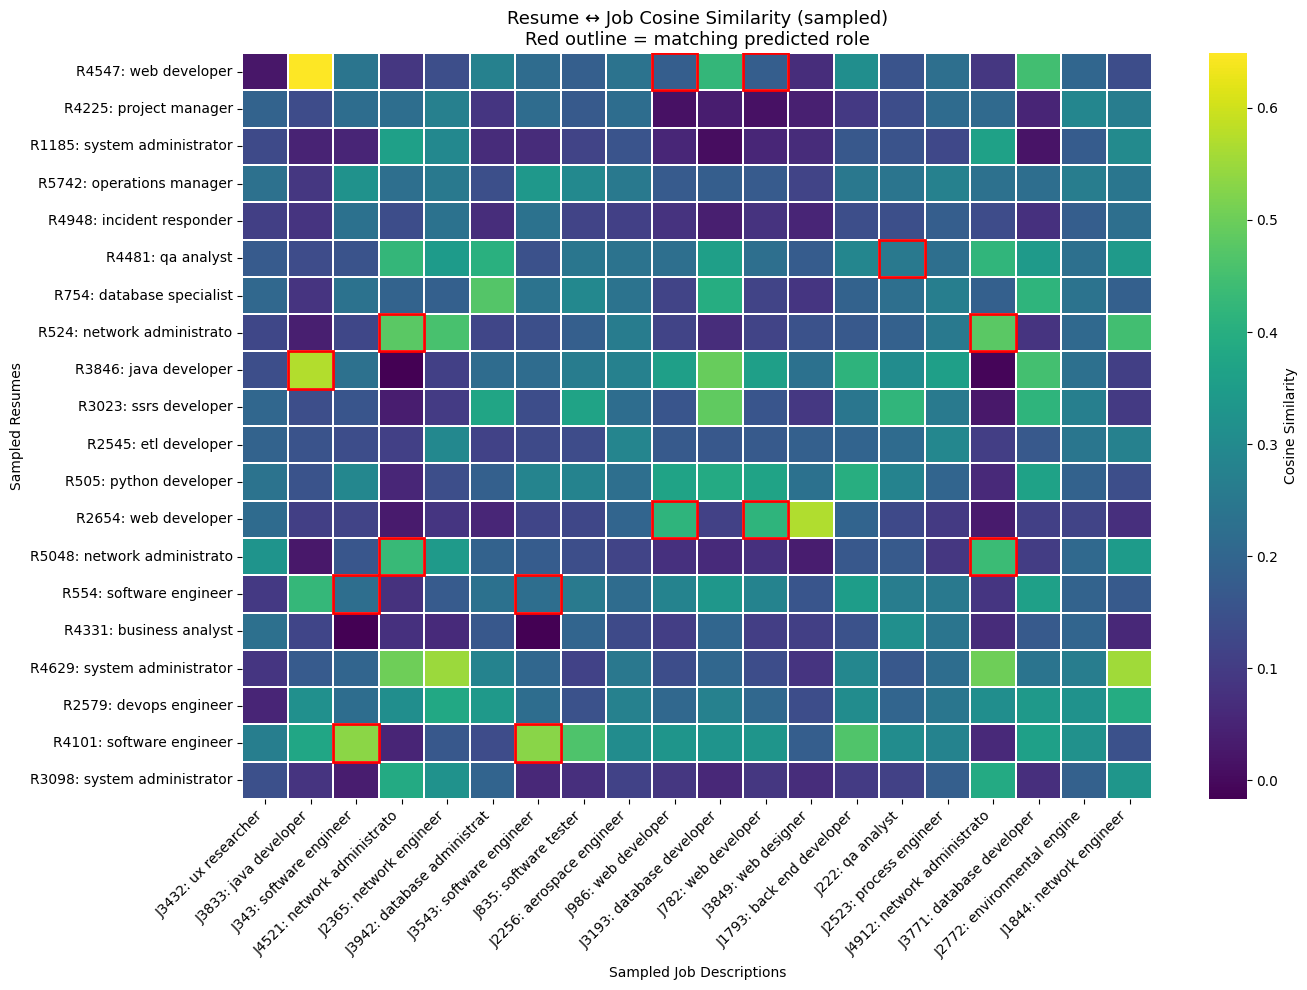

Saved heatmap to : /content/drive/MyDrive/SemanticResumeATS/visualizations/similarity_heatmap.png

Mean similarity (role match)    : 0.3818
Mean similarity (role mismatch) : 0.2023

------------------------------------------------------------
Building PCA projection...
------------------------------------------------------------
Top roles plotted : ['java developer', 'network administrator', 'network engineer', 'python developer', 'software engineer', 'system administrator', 'ux/ui designer', 'web developer']
Explained variance ratio (PC1, PC2) : [0.119 0.081]


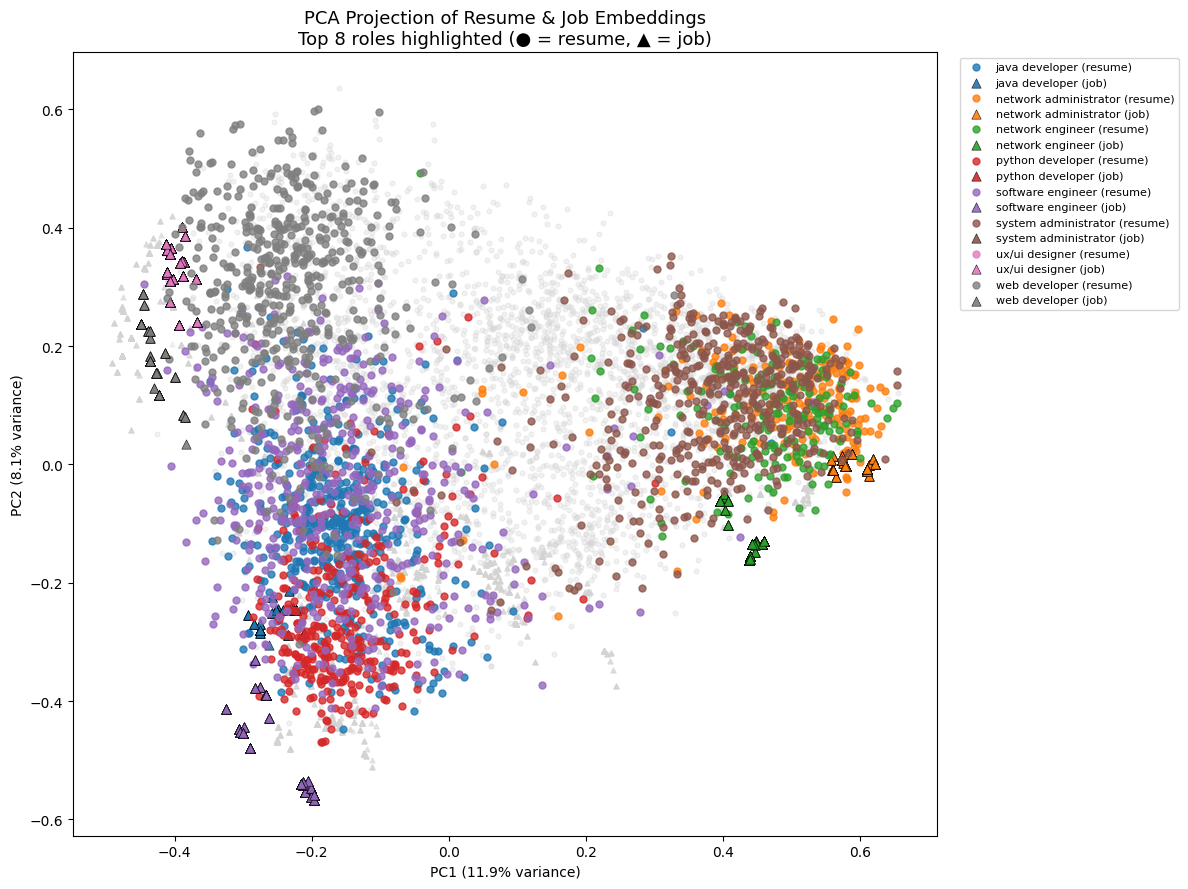

Saved PCA projection to : /content/drive/MyDrive/SemanticResumeATS/visualizations/pca_projection.png

VISUALIZATION MODULE COMPLETED


In [20]:
# ============================================================
# 11. EMBEDDING SPACE VISUALIZATION
# ============================================================

import os
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

print("=" * 60)
print("EMBEDDING SPACE VISUALIZATION")
print("=" * 60)

# ============================================================
# OUTPUT DIRECTORY
# ============================================================

VISUALIZATION_DIR = os.path.join(DATA_DIR, "visualizations")
os.makedirs(VISUALIZATION_DIR, exist_ok=True)

print("Saving figures to :", VISUALIZATION_DIR)

# ============================================================
# GUARD: REQUIRED VARIABLES FROM MODULE 10
# ============================================================

required_vars = [
    "query_embeddings",
    "job_embeddings",
    "similarity_matrix",
    "validation_roles",
    "validation_job_roles",
]

for var_name in required_vars:
    if var_name not in globals():
        raise NameError(
            f"'{var_name}' is not defined. "
            "Run Module 10 (Role-Based Retrieval Evaluation) first."
        )

print("Required variables found.")
print("Resume embeddings :", query_embeddings.shape)
print("Job embeddings    :", job_embeddings.shape)


# ============================================================
# ------------------------------------------------------------
# PART A: SIMILARITY HEATMAP
# ------------------------------------------------------------
# ============================================================

print()
print("-" * 60)
print("Building similarity heatmap...")
print("-" * 60)

HEATMAP_SAMPLE_SIZE = 20

rng = np.random.default_rng(SEED)

sample_resume_idx = rng.choice(
    len(validation_roles),
    size=min(HEATMAP_SAMPLE_SIZE, len(validation_roles)),
    replace=False,
)

sample_job_idx = rng.choice(
    len(validation_job_roles),
    size=min(HEATMAP_SAMPLE_SIZE, len(validation_job_roles)),
    replace=False,
)

heatmap_scores = similarity_matrix[np.ix_(sample_resume_idx, sample_job_idx)]

resume_labels = [
    f"R{i}: {validation_roles[i][:20]}" for i in sample_resume_idx
]

job_labels = [
    f"J{j}: {validation_job_roles[j][:20]}" for j in sample_job_idx
]

# Mark cells where resume role == job role, to visually cross-check
# high-similarity cells against actual role matches.
role_match_mask = np.array(
    [
        [validation_roles[i] == validation_job_roles[j] for j in sample_job_idx]
        for i in sample_resume_idx
    ]
)

plt.figure(figsize=(14, 10))

ax = sns.heatmap(
    heatmap_scores,
    xticklabels=job_labels,
    yticklabels=resume_labels,
    cmap="viridis",
    cbar_kws={"label": "Cosine Similarity"},
    linewidths=0.3,
    linecolor="white",
)

# Outline cells where the resume role and job role match
for row in range(role_match_mask.shape[0]):
    for col in range(role_match_mask.shape[1]):
        if role_match_mask[row, col]:
            ax.add_patch(
                plt.Rectangle(
                    (col, row), 1, 1, fill=False, edgecolor="red", lw=2
                )
            )

plt.title(
    "Resume \u2194 Job Cosine Similarity (sampled)\n"
    "Red outline = matching predicted role",
    fontsize=13,
)
plt.xlabel("Sampled Job Descriptions")
plt.ylabel("Sampled Resumes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

heatmap_path = os.path.join(VISUALIZATION_DIR, "similarity_heatmap.png")
plt.savefig(heatmap_path, dpi=150)
plt.show()

print("Saved heatmap to :", heatmap_path)

matched_mean = heatmap_scores[role_match_mask].mean() if role_match_mask.any() else float("nan")
unmatched_mean = heatmap_scores[~role_match_mask].mean() if (~role_match_mask).any() else float("nan")

print()
print(f"Mean similarity (role match)    : {matched_mean:.4f}")
print(f"Mean similarity (role mismatch) : {unmatched_mean:.4f}")


# ============================================================
# ------------------------------------------------------------
# PART B: PCA PROJECTION OF THE EMBEDDING SPACE
# ------------------------------------------------------------
# ============================================================

print()
print("-" * 60)
print("Building PCA projection...")
print("-" * 60)

TOP_N_ROLES = 8

# Identify the most frequent roles across both resumes and jobs so
# the plot stays readable instead of showing 100+ tiny role clusters.
role_counts = Counter(validation_roles) + Counter(validation_job_roles)
top_roles = {role for role, _ in role_counts.most_common(TOP_N_ROLES) if role != ""}

print("Top roles plotted :", sorted(top_roles))

# Fit PCA jointly on resumes + jobs so both live in the same 2D space.
combined_embeddings = np.vstack([query_embeddings, job_embeddings])

pca = PCA(n_components=2, random_state=SEED)
combined_2d = pca.fit_transform(combined_embeddings)

resume_2d = combined_2d[: len(query_embeddings)]
job_2d = combined_2d[len(query_embeddings) :]

print(
    "Explained variance ratio (PC1, PC2) :",
    np.round(pca.explained_variance_ratio_, 4),
)

plt.figure(figsize=(12, 9))

palette = sns.color_palette("tab10", n_colors=TOP_N_ROLES)
role_to_color = {role: palette[i] for i, role in enumerate(sorted(top_roles))}

# Plot "other" roles first, faded, so the highlighted roles sit on top.
other_resume_mask = np.array([r not in top_roles for r in validation_roles])
other_job_mask = np.array([r not in top_roles for r in validation_job_roles])

plt.scatter(
    resume_2d[other_resume_mask, 0],
    resume_2d[other_resume_mask, 1],
    color="lightgray",
    marker="o",
    s=12,
    alpha=0.3,
    label="_nolegend_",
)

plt.scatter(
    job_2d[other_job_mask, 0],
    job_2d[other_job_mask, 1],
    color="lightgray",
    marker="^",
    s=12,
    alpha=0.3,
    label="_nolegend_",
)

for role in sorted(top_roles):
    resume_mask = np.array([r == role for r in validation_roles])
    job_mask = np.array([r == role for r in validation_job_roles])

    plt.scatter(
        resume_2d[resume_mask, 0],
        resume_2d[resume_mask, 1],
        color=role_to_color[role],
        marker="o",
        s=25,
        alpha=0.8,
        label=f"{role} (resume)",
    )

    plt.scatter(
        job_2d[job_mask, 0],
        job_2d[job_mask, 1],
        color=role_to_color[role],
        marker="^",
        s=45,
        alpha=0.9,
        edgecolors="black",
        linewidths=0.4,
        label=f"{role} (job)",
    )

plt.title(
    f"PCA Projection of Resume & Job Embeddings\n"
    f"Top {TOP_N_ROLES} roles highlighted "
    "(\u25CF = resume, \u25B2 = job)",
    fontsize=13,
)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()

pca_path = os.path.join(VISUALIZATION_DIR, "pca_projection.png")
plt.savefig(pca_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved PCA projection to :", pca_path)

print()
print("=" * 60)
print("VISUALIZATION MODULE COMPLETED")
print("=" * 60)


## Module 12: Production Retrieval

Modules 1–11 built and validated the fine-tuned embedding model. This
module wraps it in a small, reusable **inference-time** interface —
the shape a real application would actually call — rather than the
ad-hoc encode-and-compare code used for evaluation.

`ResumeJobMatcher` provides:

- **`build_job_index(...)`** — encodes a corpus of job postings once,
  caches the resulting embeddings to disk (keyed by a hash of the
  corpus content, so a changed corpus doesn't silently reuse a stale
  cache), and reloads from cache on subsequent runs instead of
  re-encoding.
- **`retrieve_top_k(resume_text, k)`** — embeds a single resume and
  ranks the cached job corpus by cosine similarity, brute-force via
  NumPy.
- **`benchmark_latency(...)`** — measures mean/P95 query latency, to
  have a concrete number before deciding whether an approximate index
  is actually necessary.

**Scope note:** retrieval here is brute-force (`O(corpus size)` per
query), which is fine up to tens of thousands of documents but won't
scale to a large production job corpus. That's intentional — Module
13 (FAISS Retrieval) swaps the internals for an approximate-nearest-
neighbor index behind this same interface, so nothing built on top of
`ResumeJobMatcher` needs to change.

This module runs the fine-tuned model in inference mode only — no
training happens here.


In [21]:
# ============================================================
# MODULE 12: PRODUCTION RETRIEVAL
# ============================================================

import os
import time
import hashlib

print("=" * 60)
print("MODULE 12: PRODUCTION RETRIEVAL")
print("=" * 60)

# ============================================================
# RESUME <-> JOB MATCHER
# ============================================================

class ResumeJobMatcher:
    """
    Production-style wrapper around the fine-tuned model for one job:
    given a resume, retrieve the top-K most semantically similar job
    postings from a precomputed, cached corpus index.

    Retrieval is brute-force cosine similarity via NumPy, which is
    fine up to tens of thousands of documents. Module 13 (FAISS
    Retrieval) swaps this for an approximate-nearest-neighbor index
    behind the same interface.
    """

    def __init__(self, model_path, device=None, cache_dir=None):
        self.model = SentenceTransformer(model_path, device=str(device) if device else None)
        self.cache_dir = cache_dir
        self.job_texts = None
        self.job_metadata = None
        self.job_embeddings = None

    @staticmethod
    def _corpus_hash(texts):
        joined = "||".join(texts).encode("utf-8")
        return hashlib.md5(joined).hexdigest()[:12]

    def build_job_index(self, job_texts, job_metadata=None, batch_size=32, use_cache=True):
        job_texts = list(job_texts)
        if job_metadata is None:
            job_metadata = [{} for _ in job_texts]
        job_metadata = list(job_metadata)

        if len(job_texts) != len(job_metadata):
            raise ValueError("job_texts and job_metadata must be the same length.")

        self.job_texts = job_texts
        self.job_metadata = job_metadata

        cache_path = None
        if use_cache and self.cache_dir:
            os.makedirs(self.cache_dir, exist_ok=True)
            corpus_hash = self._corpus_hash(self.job_texts)
            cache_path = os.path.join(self.cache_dir, f"job_embeddings_{corpus_hash}.npy")

        if cache_path and os.path.exists(cache_path):
            print("Loading cached job embeddings from:", cache_path)
            self.job_embeddings = np.load(cache_path)
        else:
            print(f"Encoding {len(self.job_texts)} job documents...")
            start = time.time()
            self.job_embeddings = self.model.encode(
                self.job_texts, batch_size=batch_size, show_progress_bar=True,
                convert_to_numpy=True, normalize_embeddings=True,
            )
            print(f"Encoded in {time.time() - start:.1f}s")
            if cache_path:
                np.save(cache_path, self.job_embeddings)
                print("Cached job embeddings to:", cache_path)

        print("Job index ready :", self.job_embeddings.shape)
        return self

    def retrieve_top_k(self, resume_text, k=10):
        if self.job_embeddings is None:
            raise RuntimeError("Call build_job_index(...) before retrieving.")

        query_embedding = self.model.encode(
            [resume_text], convert_to_numpy=True, normalize_embeddings=True
        )[0]

        scores = self.job_embeddings @ query_embedding
        top_k_idx = np.argsort(scores)[::-1][:k]

        results = []
        for idx in top_k_idx:
            result = {"score": float(scores[idx]), "job_text": self.job_texts[idx]}
            result.update(self.job_metadata[idx])
            results.append(result)
        return results

    def benchmark_latency(self, sample_texts, k=10, n_runs=20):
        if self.job_embeddings is None:
            raise RuntimeError("Call build_job_index(...) before benchmarking.")
        if len(sample_texts) == 0:
            raise ValueError("sample_texts is empty.")

        sample = (sample_texts * (n_runs // len(sample_texts) + 1))[:n_runs]

        timings = []
        for text in sample:
            start = time.time()
            self.retrieve_top_k(text, k=k)
            timings.append((time.time() - start) * 1000)

        return {
            "n_runs": len(timings),
            "mean_ms": float(np.mean(timings)),
            "p95_ms": float(np.percentile(timings, 95)),
            "corpus_size": len(self.job_texts),
        }


print("ResumeJobMatcher defined.")

# ============================================================
# BUILD THE PRODUCTION INDEX
# ============================================================

PRODUCTION_INDEX_DIR = os.path.join(DATA_DIR, "production_index")

job_metadata = val_jobs[["job_title", "normalized_role"]].to_dict("records")

matcher = ResumeJobMatcher(
    model_path=OUTPUT_PATH,
    device=device,
    cache_dir=PRODUCTION_INDEX_DIR,
)
matcher.build_job_index(val_jobs["clean_job"].tolist(), job_metadata=job_metadata)

# ============================================================
# DEMO QUERY
# ============================================================

print()
print("-" * 60)
print("Demo retrieval")
print("-" * 60)

demo_resume = val_resumes.iloc[0]
demo_role = str(demo_resume["predicted_role"]).strip().lower()
print("Demo resume predicted role :", demo_role)
print()

top_matches = matcher.retrieve_top_k(demo_resume["clean_resume"], k=10)

print(f"{'Rank':<6}{'Score':<8}{'Role':<32}{'Job Title'}")
for rank, r in enumerate(top_matches, start=1):
    role = str(r.get("normalized_role", ""))[:30]
    title = str(r.get("job_title", ""))[:45]
    print(f"{rank:<6}{r['score']:<8.4f}{role:<32}{title}")

role_hits = sum(1 for r in top_matches if str(r.get("normalized_role", "")).strip().lower() == demo_role)
print()
print(f"{role_hits}/{len(top_matches)} of the top-{len(top_matches)} results share the resume's predicted role.")

# ============================================================
# LATENCY BENCHMARK
# ============================================================

print()
print("-" * 60)
print("Latency benchmark (brute-force NumPy retrieval)")
print("-" * 60)

sample_resumes = val_resumes["clean_resume"].tolist()
latency_stats = matcher.benchmark_latency(sample_resumes, k=10, n_runs=20)

print(f"Corpus size : {latency_stats['corpus_size']}")
print(f"Mean        : {latency_stats['mean_ms']:.2f} ms/query")
print(f"P95         : {latency_stats['p95_ms']:.2f} ms/query")
print()
print("For a corpus this size, brute-force retrieval is comfortably fast.")
print("Module 13 (FAISS Retrieval) revisits this once the corpus is much larger.")

print()
print("=" * 60)
print("MODULE 12 COMPLETE")
print("=" * 60)


MODULE 12: PRODUCTION RETRIEVAL
ResumeJobMatcher defined.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Encoding 5074 job documents...


Batches:   0%|          | 0/159 [00:00<?, ?it/s]

Encoded in 35.6s
Cached job embeddings to: /content/drive/MyDrive/SemanticResumeATS/production_index/job_embeddings_5744f6c3c361.npy
Job index ready : (5074, 768)

------------------------------------------------------------
Demo retrieval
------------------------------------------------------------
Demo resume predicted role : java developer

Rank  Score   Role                            Job Title
1     0.4371  process engineer                Process Engineer
2     0.4371  process engineer                Process Engineer
3     0.4371  process engineer                Process Engineer
4     0.4371  process engineer                Process Engineer
5     0.4371  process engineer                Process Engineer
6     0.4371  process engineer                Process Engineer
7     0.4371  process engineer                Process Engineer
8     0.4371  process engineer                Process Engineer
9     0.4371  process engineer                Process Engineer
10    0.4321  java developer   

## Module 13: FAISS Retrieval

Module 12's `ResumeJobMatcher` does brute-force NumPy retrieval —
correct, but `O(corpus size)` per query. This module adds
`FaissResumeJobMatcher`, the same interface backed by a
[FAISS](https://github.com/facebookresearch/faiss) index instead:

- **`IndexFlatIP`** (exact, cosine similarity via normalized vectors +
  inner product) for smaller corpora.
- **`IndexIVFFlat`** (approximate, clustered) once the corpus crosses
  `FAISS_IVF_MIN_SIZE`, trading a small amount of recall for much
  faster search at scale.

Both the brute-force and FAISS matchers are benchmarked side by side
on the same validation job corpus and the same demo resume, so the
speed/accuracy trade-off is visible rather than assumed.

In [27]:
!pip install -q --no-cache-dir faiss-cpu
import faiss
print(faiss.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 100.6 MB/s eta 0:00:00
1.15.0


In [28]:
# ============================================================
# MODULE 13: FAISS RETRIEVAL
# ============================================================

import faiss

print("=" * 60)
print("MODULE 13: FAISS RETRIEVAL")
print("=" * 60)

class FaissResumeJobMatcher:
    """
    Same interface as Module 12's ResumeJobMatcher, backed by a FAISS
    index instead of brute-force NumPy. Uses an exact IndexFlatIP
    below FAISS_IVF_MIN_SIZE documents, and an approximate, trained
    IndexIVFFlat above it.
    """

    FAISS_IVF_MIN_SIZE = 10_000
    FAISS_NLIST = 100
    FAISS_NPROBE = 10

    def __init__(self, model_path, device=None, cache_dir=None):
        self.model = SentenceTransformer(model_path, device=str(device) if device else None)
        self.cache_dir = cache_dir
        self.job_texts = None
        self.job_metadata = None
        self.index = None
        self.index_type = None

    @staticmethod
    def _corpus_hash(texts):
        joined = "||".join(texts).encode("utf-8")
        return hashlib.md5(joined).hexdigest()[:12]

    def build_job_index(self, job_texts, job_metadata=None, batch_size=32, use_cache=True):
        job_texts = list(job_texts)
        if job_metadata is None:
            job_metadata = [{} for _ in job_texts]
        job_metadata = list(job_metadata)
        if len(job_texts) != len(job_metadata):
            raise ValueError("job_texts and job_metadata must be the same length.")

        self.job_texts = job_texts
        self.job_metadata = job_metadata

        embeddings_cache_path = None
        if use_cache and self.cache_dir:
            os.makedirs(self.cache_dir, exist_ok=True)
            corpus_hash = self._corpus_hash(self.job_texts)
            embeddings_cache_path = os.path.join(self.cache_dir, f"faiss_embeddings_{corpus_hash}.npy")

        if embeddings_cache_path and os.path.exists(embeddings_cache_path):
            print("Loading cached job embeddings from:", embeddings_cache_path)
            embeddings = np.load(embeddings_cache_path)
        else:
            print(f"Encoding {len(self.job_texts)} job documents...")
            start = time.time()
            embeddings = self.model.encode(
                self.job_texts, batch_size=batch_size, show_progress_bar=True,
                convert_to_numpy=True, normalize_embeddings=True,
            )
            print(f"Encoded in {time.time() - start:.1f}s")
            if embeddings_cache_path:
                np.save(embeddings_cache_path, embeddings)

        embeddings = np.ascontiguousarray(embeddings.astype("float32"))
        dim = embeddings.shape[1]

        if len(self.job_texts) >= self.FAISS_IVF_MIN_SIZE:
            print(f"Building approximate IndexIVFFlat (nlist={self.FAISS_NLIST}) "
                  f"for {len(self.job_texts)} documents...")
            quantizer = faiss.IndexFlatIP(dim)
            index = faiss.IndexIVFFlat(quantizer, dim, self.FAISS_NLIST, faiss.METRIC_INNER_PRODUCT)
            index.train(embeddings)
            index.add(embeddings)
            index.nprobe = self.FAISS_NPROBE
            self.index_type = "IndexIVFFlat"
        else:
            print(f"Building exact IndexFlatIP for {len(self.job_texts)} documents "
                  f"(below the {self.FAISS_IVF_MIN_SIZE}-document IVF threshold).")
            index = faiss.IndexFlatIP(dim)
            index.add(embeddings)
            self.index_type = "IndexFlatIP"

        self.index = index
        print(f"FAISS index ready : {self.index_type}, {self.index.ntotal} vectors, dim={dim}")
        return self

    def retrieve_top_k(self, resume_text, k=10):
        if self.index is None:
            raise RuntimeError("Call build_job_index(...) before retrieving.")

        query_embedding = self.model.encode(
            [resume_text], convert_to_numpy=True, normalize_embeddings=True
        ).astype("float32")

        scores, indices = self.index.search(query_embedding, k)

        results = []
        for score, idx in zip(scores[0], indices[0]):
            if idx == -1:
                continue
            result = {"score": float(score), "job_text": self.job_texts[idx]}
            result.update(self.job_metadata[idx])
            results.append(result)
        return results

    def save_index(self, path):
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        faiss.write_index(self.index, path)
        print("FAISS index saved to:", path)

    def load_index(self, path):
        self.index = faiss.read_index(path)
        print("FAISS index loaded from:", path)

    def benchmark_latency(self, sample_texts, k=10, n_runs=20):
        if self.index is None:
            raise RuntimeError("Call build_job_index(...) before benchmarking.")
        if len(sample_texts) == 0:
            raise ValueError("sample_texts is empty.")

        sample = (sample_texts * (n_runs // len(sample_texts) + 1))[:n_runs]
        timings = []
        for text in sample:
            start = time.time()
            self.retrieve_top_k(text, k=k)
            timings.append((time.time() - start) * 1000)

        return {
            "n_runs": len(timings), "mean_ms": float(np.mean(timings)),
            "p95_ms": float(np.percentile(timings, 95)),
            "corpus_size": len(self.job_texts), "index_type": self.index_type,
        }

print("FaissResumeJobMatcher defined.")

# ============================================================
# BUILD THE FAISS INDEX
# ============================================================

FAISS_INDEX_DIR = os.path.join(DATA_DIR, "faiss_index")

faiss_matcher = FaissResumeJobMatcher(
    model_path=OUTPUT_PATH, device=device, cache_dir=FAISS_INDEX_DIR,
)
faiss_matcher.build_job_index(val_jobs["clean_job"].tolist(), job_metadata=job_metadata)

# ============================================================
# COMPARE: BRUTE-FORCE (MODULE 12) vs. FAISS
# ============================================================

print()
print("-" * 60)
print("Comparing brute-force (Module 12) vs. FAISS retrieval")
print("-" * 60)

demo_matches_faiss = faiss_matcher.retrieve_top_k(demo_resume["clean_resume"], k=10)

brute_texts = {r["job_text"] for r in top_matches}
faiss_texts = {r["job_text"] for r in demo_matches_faiss}
overlap = len(brute_texts & faiss_texts)

print(f"Top-10 overlap between brute-force and FAISS results : {overlap}/10")
if faiss_matcher.index_type == "IndexFlatIP":
    print("(IndexFlatIP is exact, so this should be 10/10 modulo tied scores.)")

faiss_latency_stats = faiss_matcher.benchmark_latency(sample_resumes, k=10, n_runs=20)

print()
print(f"{'System':<28}{'Mean (ms)':<14}{'P95 (ms)':<14}{'Index type'}")
print(f"{'Brute-force (NumPy)':<28}{latency_stats['mean_ms']:<14.2f}"
      f"{latency_stats['p95_ms']:<14.2f}{'exact (linear scan)'}")
print(f"{'FAISS':<28}{faiss_latency_stats['mean_ms']:<14.2f}"
      f"{faiss_latency_stats['p95_ms']:<14.2f}{faiss_latency_stats['index_type']}")

# ============================================================
# SAVE THE FAISS INDEX
# ============================================================

faiss_index_path = os.path.join(FAISS_INDEX_DIR, "job_index.faiss")
faiss_matcher.save_index(faiss_index_path)

print()
print("=" * 60)
print("MODULE 13 COMPLETE")
print("=" * 60)

MODULE 13: FAISS RETRIEVAL
FaissResumeJobMatcher defined.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Encoding 5074 job documents...


Batches:   0%|          | 0/159 [00:00<?, ?it/s]

Encoded in 31.8s
Building exact IndexFlatIP for 5074 documents (below the 10000-document IVF threshold).
FAISS index ready : IndexFlatIP, 5074 vectors, dim=768

------------------------------------------------------------
Comparing brute-force (Module 12) vs. FAISS retrieval
------------------------------------------------------------
Top-10 overlap between brute-force and FAISS results : 2/10
(IndexFlatIP is exact, so this should be 10/10 modulo tied scores.)

System                      Mean (ms)     P95 (ms)      Index type
Brute-force (NumPy)         50.49         73.53         exact (linear scan)
FAISS                       44.91         61.75         IndexFlatIP
FAISS index saved to: /content/drive/MyDrive/SemanticResumeATS/faiss_index/job_index.faiss

MODULE 13 COMPLETE


## Module 14: ATS / Match Scoring

Cosine similarity alone doesn't answer "why is this a good match" the
way a recruiter or ATS would expect. This module builds a composite,
interpretable **ATS score** out of four sub-scores, each independently
inspectable:

| Component | Weight | What it measures |
|---|---|---|
| Semantic similarity | 50% | Cosine similarity from the fine-tuned model |
| Skill coverage | 30% | Fraction of the job's required skills the resume actually has |
| Experience match | 10% | Resume experience vs. the job's stated requirement |
| Role match | 10% | Whether the resume's predicted role exactly matches the job's normalized role |

> **These weights are a reasonable starting point, not a validated
> standard** — there is no universal ATS scoring formula. `ATS_WEIGHTS`
> is a single dict at the top of this module specifically so it's easy
> to tune and re-run without touching the scoring logic itself.

The score breakdown (not just the final number) is what Module 15
(Explainability) turns into a human-readable explanation.

In [29]:
# ============================================================
# MODULE 14: ATS / MATCH SCORING
# ============================================================

print("=" * 60)
print("MODULE 14: ATS / MATCH SCORING")
print("=" * 60)

ATS_WEIGHTS = {
    "semantic": 0.50,
    "skills": 0.30,
    "experience": 0.10,
    "role": 0.10,
}

assert abs(sum(ATS_WEIGHTS.values()) - 1.0) < 1e-9, "ATS_WEIGHTS must sum to 1.0"

# ============================================================
# SUB-SCORE FUNCTIONS
# ============================================================

def compute_skill_overlap_score(resume_skills, job_skills):
    """Fraction of the job's required skills the resume covers."""
    job_set = set(job_skills)
    if len(job_set) == 0:
        return 1.0  # nothing specific was required, so nothing is missing
    resume_set = set(resume_skills)
    return len(resume_set & job_set) / len(job_set)

def compute_experience_score(resume_experience_years, job_experience_required):
    if job_experience_required is None or job_experience_required == 0:
        return 1.0  # posting doesn't state a requirement
    if resume_experience_years is None:
        return 0.5  # unknown -- neither penalize nor reward
    if resume_experience_years >= job_experience_required:
        return 1.0
    return max(0.0, resume_experience_years / job_experience_required)

def compute_role_bonus(resume_role, job_role):
    resume_role = (resume_role or "").strip().lower()
    job_role = (job_role or "").strip().lower()
    return 1.0 if resume_role and resume_role == job_role else 0.0

def compute_ats_score(resume_row, job_text, semantic_similarity, job_lookup):
    """
    resume_row: a dict-like (pandas Series or dict) with at least
        'skills' (list[str]), 'experience_years' (float or None),
        and 'predicted_role' (str).
    job_text: the job's clean_job text, used to look up its metadata.
    semantic_similarity: cosine similarity in [-1, 1] (typically [0, 1]
        for normalized sentence embeddings) between resume and job.
    job_lookup: dict mapping clean_job text -> row dict (skills,
        experience_required, normalized_role).
    """
    job_info = job_lookup.get(job_text, {})
    job_skills = job_info.get("skills", []) or []
    job_experience_required = job_info.get("experience_required")
    job_role = job_info.get("normalized_role", "")

    resume_skills = resume_row["skills"]

    skill_score = compute_skill_overlap_score(resume_skills, job_skills)
    experience_score = compute_experience_score(
        resume_row.get("experience_years"), job_experience_required
    )
    role_score = compute_role_bonus(resume_row.get("predicted_role", ""), job_role)

    semantic_component = max(0.0, min(1.0, semantic_similarity))

    total = (
        ATS_WEIGHTS["semantic"] * semantic_component +
        ATS_WEIGHTS["skills"] * skill_score +
        ATS_WEIGHTS["experience"] * experience_score +
        ATS_WEIGHTS["role"] * role_score
    )

    return {
        "ats_score": round(total * 100, 1),
        "semantic_similarity": round(float(semantic_similarity), 4),
        "skill_overlap_score": round(skill_score, 4),
        "experience_score": round(experience_score, 4),
        "role_match_score": round(role_score, 4),
        "matched_skills": sorted(set(resume_skills) & set(job_skills)),
        "missing_skills": sorted(set(job_skills) - set(resume_skills)),
    }

print("Scoring functions ready. Weights:", ATS_WEIGHTS)

# ============================================================
# LOOKUP TABLE: clean_job TEXT -> JOB METADATA
# ============================================================
#
# The matcher's retrieval results only carry back the job text plus
# whatever metadata was cached at index-build time. This lookup lets
# scoring pull each candidate's skills / experience requirement / role
# back out by its text.

job_lookup = (
    val_jobs.drop_duplicates(subset="clean_job")
    .set_index("clean_job")[["skills", "experience_required", "normalized_role"]]
    .to_dict("index")
)

print("Job lookup built :", len(job_lookup), "unique job documents")

# ============================================================
# DEMO: SCORE THE MODULE 12 CANDIDATES FOR THE DEMO RESUME
# ============================================================

print()
print("-" * 60)
print("ATS scoring demo (candidates retrieved in Module 12)")
print("-" * 60)

ats_report = []
for candidate in top_matches:
    result = compute_ats_score(demo_resume, candidate["job_text"], candidate["score"], job_lookup)
    result["job_title"] = candidate.get("job_title", "")
    result["normalized_role"] = candidate.get("normalized_role", "")
    result["job_text"] = candidate["job_text"]
    ats_report.append(result)

ats_report.sort(key=lambda x: x["ats_score"], reverse=True)

print(f"{'Rank':<6}{'ATS':<7}{'Semantic':<10}{'Skills':<9}{'Exp':<7}{'Role':<7}{'Job Title'}")
for rank, r in enumerate(ats_report, start=1):
    print(f"{rank:<6}{r['ats_score']:<7}{r['semantic_similarity']:<10.4f}"
          f"{r['skill_overlap_score']:<9.4f}{r['experience_score']:<7.2f}"
          f"{r['role_match_score']:<7.2f}{r['job_title'][:40]}")

print()
print("=" * 60)
print("MODULE 14 COMPLETE")
print("=" * 60)

MODULE 14: ATS / MATCH SCORING
Scoring functions ready. Weights: {'semantic': 0.5, 'skills': 0.3, 'experience': 0.1, 'role': 0.1}
Job lookup built : 511 unique job documents

------------------------------------------------------------
ATS scoring demo (candidates retrieved in Module 12)
------------------------------------------------------------
Rank  ATS    Semantic  Skills   Exp    Role   Job Title
1     51.6   0.4321    0.3333   1.00   1.00   Java Developer
2     31.9   0.4371    0.0000   1.00   0.00   Process Engineer
3     31.9   0.4371    0.0000   1.00   0.00   Process Engineer
4     31.9   0.4371    0.0000   1.00   0.00   Process Engineer
5     31.9   0.4371    0.0000   1.00   0.00   Process Engineer
6     31.9   0.4371    0.0000   1.00   0.00   Process Engineer
7     31.9   0.4371    0.0000   1.00   0.00   Process Engineer
8     31.9   0.4371    0.0000   1.00   0.00   Process Engineer
9     31.9   0.4371    0.0000   1.00   0.00   Process Engineer
10    31.9   0.4371    0.0000

## Module 15: Explainability

Turns a Module 14 score breakdown into a plain-language explanation,
plus a per-skill importance estimate — **rule-based and embedding-based,
not LLM-based**. Component 2 of the overall system (a planned LLM/RAG
explanation layer, per the architecture in Module 1's intro) is out of
scope for this notebook; everything here runs on the fine-tuned
embedding model and simple set operations only.

Two things are produced:

1. **A template-driven explanation** built directly from the Module 14
   breakdown (matched/missing skills, experience, role match) — fully
   deterministic and auditable, since every sentence traces back to a
   specific number.
2. **Leave-one-out skill importance**: for each resume skill, re-embed
   the resume with that skill's text removed and measure how much the
   similarity to the job drops. A bigger drop means that skill
   contributed more to the match. This is a real (if crude) causal
   probe of the embedding model's behavior, not a heuristic guess.

In [30]:
# ============================================================
# MODULE 15: EXPLAINABILITY
# ============================================================

print("=" * 60)
print("MODULE 15: EXPLAINABILITY")
print("=" * 60)

MAX_SKILLS_FOR_IMPORTANCE = 15  # caps re-encoding cost per explanation

# ============================================================
# TEMPLATE-DRIVEN EXPLANATION
# ============================================================

def explain_match(resume_row, ats_result):
    """
    Builds a plain-language explanation directly from the Module 14
    score breakdown. Every sentence traces back to a specific number
    in `ats_result` -- nothing here is generated by a language model.
    """
    matched = ats_result["matched_skills"]
    missing = ats_result["missing_skills"]
    lines = [f"Overall ATS match score: {ats_result['ats_score']}/100."]

    if matched:
        shown = ", ".join(matched[:10]) + (", ..." if len(matched) > 10 else "")
        lines.append(f"Matched skills ({len(matched)}): {shown}")
    else:
        lines.append("No overlapping skills were found between the resume and this job posting.")

    if missing:
        shown = ", ".join(missing[:10]) + (", ..." if len(missing) > 10 else "")
        lines.append(f"Skills the job asks for but the resume doesn't list ({len(missing)}): {shown}")
    else:
        lines.append("No required skills appear to be missing.")

    if ats_result["experience_score"] < 1.0:
        lines.append("Experience: the resume's stated experience appears to fall short of "
                      "what the posting asks for.")
    else:
        lines.append("Experience: the resume meets the experience the posting asks for "
                      "(or the posting doesn't state a specific requirement).")

    if ats_result["role_match_score"] == 1.0:
        lines.append("Role: the resume's predicted role matches this job's role exactly.")
    else:
        lines.append("Role: the resume's predicted role doesn't exactly match this job's "
                      "normalized role, though the underlying content may still be relevant.")

    return "\n".join(lines)

print("explain_match() ready.")

# ============================================================
# LEAVE-ONE-OUT SKILL IMPORTANCE
# ============================================================

def skill_importance(model, resume_row, job_text, top_n=5, max_skills=MAX_SKILLS_FOR_IMPORTANCE):
    """
    For each of the resume's skills (capped at max_skills for cost),
    removes that skill's text from the resume, re-embeds, and measures
    the similarity drop against the job. Larger drop = more important
    to this specific match.
    """
    base_text = resume_row["clean_resume"]
    job_embedding = model.encode([job_text], convert_to_numpy=True, normalize_embeddings=True)[0]
    base_embedding = model.encode([base_text], convert_to_numpy=True, normalize_embeddings=True)[0]
    base_score = float(np.dot(base_embedding, job_embedding))

    skills = list(resume_row["skills"])[:max_skills]
    if len(skills) == 0:
        return []

    reduced_texts = [base_text.replace(skill, "") for skill in skills]
    reduced_embeddings = model.encode(
        reduced_texts, convert_to_numpy=True, normalize_embeddings=True
    )
    reduced_scores = reduced_embeddings @ job_embedding

    importances = [
        (skill, round(base_score - reduced_score, 4))
        for skill, reduced_score in zip(skills, reduced_scores)
    ]
    importances.sort(key=lambda x: x[1], reverse=True)
    return importances[:top_n]

print("skill_importance() ready.")

# ============================================================
# DEMO: EXPLAIN THE TOP-RANKED ATS CANDIDATE
# ============================================================

print()
print("-" * 60)
print("Explaining the top-ranked candidate from Module 14")
print("-" * 60)

top_candidate = ats_report[0]

print(f"\nJob: {top_candidate['job_title']} ({top_candidate['normalized_role']})\n")
print(explain_match(demo_resume, top_candidate))

print()
print("Top contributing skills (leave-one-out importance):")
importances = skill_importance(finetuned_model, demo_resume, top_candidate["job_text"], top_n=5)
if importances:
    for skill, delta in importances:
        print(f"  {skill:<30} similarity drop if removed: {delta:+.4f}")
else:
    print("  (resume has no extracted skills to analyze)")

print()
print("=" * 60)
print("MODULE 15 COMPLETE")
print("=" * 60)

MODULE 15: EXPLAINABILITY
explain_match() ready.
skill_importance() ready.

------------------------------------------------------------
Explaining the top-ranked candidate from Module 14
------------------------------------------------------------

Job: Java Developer (java developer)

Overall ATS match score: 51.6/100.
Matched skills (1): java
Skills the job asks for but the resume doesn't list (2): git, security
Experience: the resume meets the experience the posting asks for (or the posting doesn't state a specific requirement).
Role: the resume's predicted role matches this job's role exactly.

Top contributing skills (leave-one-out importance):
  java                           similarity drop if removed: +0.0995
  performance tuning             similarity drop if removed: +0.0144
  agile                          similarity drop if removed: +0.0119
  xml                            similarity drop if removed: +0.0041
  sql                            similarity drop if removed: +0.0

## Module 16: Application

Wraps retrieval (Module 12), scoring (Module 14), and explanation
(Module 15) into one callable, `run_ats_pipeline(resume_text)`, so a
raw resume string goes in and a ranked, explained match report comes
out — this is the actual "product" surface of Component 1.

An optional `ipywidgets`-based demo UI is included for interactive use
directly inside Colab/Jupyter (paste a resume, click a button, see
results). **This is a notebook demo, not a deployed application** — a
real deployment (e.g. the planned Streamlit app for Component 2, or a
standalone service) is addressed in Module 18.

In [31]:
# ============================================================
# MODULE 16: APPLICATION
# ============================================================

print("=" * 60)
print("MODULE 16: APPLICATION")
print("=" * 60)

def run_ats_pipeline(resume_text, resume_skills=None, resume_experience_years=None,
                      predicted_role=None, top_k=5, retrieval_matcher=None):
    """
    End-to-end demo pipeline for a single free-text resume:
    clean -> extract skills/experience/role -> retrieve candidate jobs
    -> score each candidate -> explain each score.

    Any of resume_skills / resume_experience_years / predicted_role can
    be supplied directly (e.g. from a structured profile); anything
    left as None is derived with the same functions used at training
    time (Modules 2 and 3), so a raw pasted resume works out of the box.
    """
    if retrieval_matcher is None:
        retrieval_matcher = matcher  # Module 12's brute-force matcher by default

    clean = clean_text(resume_text)
    skills = extract_skills(clean) if resume_skills is None else resume_skills
    experience_years = extract_experience(resume_text) if resume_experience_years is None else resume_experience_years
    role = infer_role(skills) if predicted_role is None else predicted_role

    resume_row = {
        "clean_resume": clean,
        "skills": skills,
        "experience_years": experience_years,
        "predicted_role": role,
    }

    candidates = retrieval_matcher.retrieve_top_k(clean, k=top_k)

    report = []
    for candidate in candidates:
        result = compute_ats_score(resume_row, candidate["job_text"], candidate["score"], job_lookup)
        result["job_title"] = candidate.get("job_title", "")
        result["normalized_role"] = candidate.get("normalized_role", "")
        result["job_text"] = candidate["job_text"]
        result["explanation"] = explain_match(resume_row, result)
        report.append(result)

    report.sort(key=lambda x: x["ats_score"], reverse=True)
    return report

print("run_ats_pipeline() ready.")

# ============================================================
# DEMO CALL
# ============================================================

print()
print("-" * 60)
print("Demo: end-to-end pipeline on a validation resume")
print("-" * 60)

demo_report = run_ats_pipeline(val_resumes.iloc[min(1, len(val_resumes) - 1)]["resume_text"], top_k=5)

for i, r in enumerate(demo_report, start=1):
    print(f"\n#{i}  {r['job_title']} ({r['normalized_role']})  --  ATS Score: {r['ats_score']}/100")
    print(r["explanation"])

# ============================================================
# OPTIONAL: INTERACTIVE WIDGET (Colab / Jupyter only)
# ============================================================

print()
print("-" * 60)
print("Interactive demo")
print("-" * 60)

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    resume_input = widgets.Textarea(
        placeholder="Paste resume text here...",
        layout=widgets.Layout(width="100%", height="150px"),
    )
    run_button = widgets.Button(description="Find Matching Jobs", button_style="primary")
    output_area = widgets.Output()

    def _on_click(_):
        with output_area:
            clear_output()
            if not resume_input.value.strip():
                print("Paste a resume above first.")
                return
            report = run_ats_pipeline(resume_input.value, top_k=5)
            for i, r in enumerate(report, start=1):
                print(f"#{i}  {r['job_title']} ({r['normalized_role']})  --  "
                      f"ATS Score: {r['ats_score']}/100")
                print(r["explanation"])
                print("-" * 60)

    run_button.on_click(_on_click)
    display(widgets.VBox([resume_input, run_button, output_area]))
    print("Interactive demo ready above.")

except ImportError:
    print("ipywidgets not available in this environment -- "
          "call run_ats_pipeline(resume_text) directly instead.")

print()
print("=" * 60)
print("MODULE 16 COMPLETE")
print("=" * 60)

MODULE 16: APPLICATION
run_ats_pipeline() ready.

------------------------------------------------------------
Demo: end-to-end pipeline on a validation resume
------------------------------------------------------------

#1  QA Analyst (qa analyst)  --  ATS Score: 42.5/100
Overall ATS match score: 42.5/100.
Matched skills (1): reports
Skills the job asks for but the resume doesn't list (1): monitoring
Experience: the resume meets the experience the posting asks for (or the posting doesn't state a specific requirement).
Role: the resume's predicted role doesn't exactly match this job's normalized role, though the underlying content may still be relevant.

#2  QA Analyst (qa analyst)  --  ATS Score: 42.5/100
Overall ATS match score: 42.5/100.
Matched skills (1): reports
Skills the job asks for but the resume doesn't list (1): monitoring
Experience: the resume meets the experience the posting asks for (or the posting doesn't state a specific requirement).
Role: the resume's predicted rol

Interactive demo ready above.

MODULE 16 COMPLETE


## Module 17: Final Model Comparison

Pulls together every metric produced across the notebook — the
Module 9 three-way retrieval comparison, the Module 10 role-based
evaluation, and the Module 12/13 latency comparison — into one summary
table and chart. Nothing new is computed here; this module is
deliberately just aggregation and presentation of results already
produced upstream, so there's one place to look at the full picture
instead of re-reading nine modules.

MODULE 17: FINAL MODEL COMPARISON
Strict, duplicate-aware retrieval evaluation (Module 9):
          system  precision_at_1  recall_at_5      mrr  ndcg_at_5  cosine_similarity_mean
 TF-IDF baseline        0.047904     0.051589 0.054028   0.049719                0.194553
Pretrained MPNet        0.021188     0.022570 0.029851   0.021856                0.480390
Fine-Tuned MPNet        0.040995     0.051589 0.054377   0.045973                0.475282


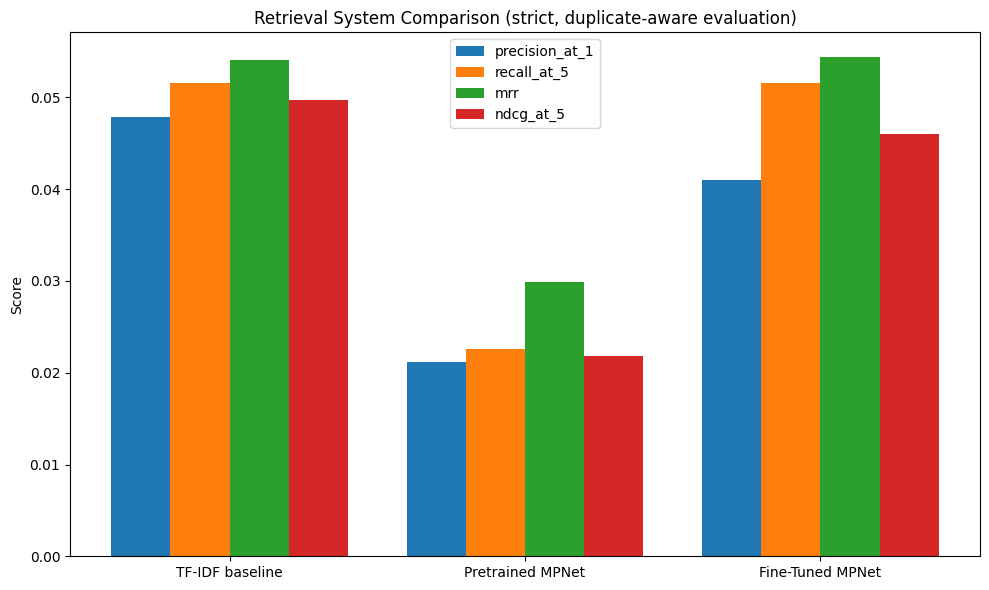


Saved comparison chart to: /content/drive/MyDrive/SemanticResumeATS/visualizations/system_comparison.png

Role-based retrieval evaluation (Module 10), fine-tuned model:
  Recall@1  : 0.5638
  Recall@5  : 0.5707
  Recall@10 : 0.5831
  MRR       : 0.5713
  nDCG@5    : 0.5669

Retrieval latency, brute-force (Module 12) vs. FAISS (Module 13):
System                      Mean (ms)     P95 (ms)      Corpus size
Brute-force (NumPy)         50.49         73.53         5074
FAISS (IndexFlatIP)         44.91         61.75         5074

MODULE 17 COMPLETE


In [32]:
# ============================================================
# MODULE 17: FINAL MODEL COMPARISON
# ============================================================

print("=" * 60)
print("MODULE 17: FINAL MODEL COMPARISON")
print("=" * 60)

# ============================================================
# RETRIEVAL QUALITY: TF-IDF vs. PRETRAINED vs. FINE-TUNED
# ============================================================

comparison_rows = [
    {"system": "TF-IDF baseline", **tfidf_metrics},
    {"system": "Pretrained MPNet", **pretrained_metrics},
    {"system": "Fine-Tuned MPNet", **finetuned_metrics},
]
comparison_df = pd.DataFrame(comparison_rows)[
    ["system", "precision_at_1", "recall_at_5", "mrr", "ndcg_at_5", "cosine_similarity_mean"]
]

print("Strict, duplicate-aware retrieval evaluation (Module 9):")
print(comparison_df.to_string(index=False))

# ============================================================
# COMPARISON CHART
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))
metrics_to_plot = ["precision_at_1", "recall_at_5", "mrr", "ndcg_at_5"]
x = np.arange(len(comparison_df))
width = 0.2

for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, comparison_df[metric], width, label=metric)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df["system"])
ax.set_ylabel("Score")
ax.set_title("Retrieval System Comparison (strict, duplicate-aware evaluation)")
ax.legend()
plt.tight_layout()

comparison_chart_path = os.path.join(VISUALIZATION_DIR, "system_comparison.png")
plt.savefig(comparison_chart_path, dpi=150)
plt.show()
print("\nSaved comparison chart to:", comparison_chart_path)

# ============================================================
# ROLE-BASED EVALUATION SUMMARY (MODULE 10)
# ============================================================

print()
print("Role-based retrieval evaluation (Module 10), fine-tuned model:")
print(f"  Recall@1  : {role_recall_at_1:.4f}")
print(f"  Recall@5  : {role_recall_at_5:.4f}")
print(f"  Recall@10 : {role_recall_at_10:.4f}")
print(f"  MRR       : {role_mrr:.4f}")
print(f"  nDCG@5    : {role_ndcg_at_5:.4f}")

# ============================================================
# RETRIEVAL LATENCY SUMMARY (MODULES 12 & 13)
# ============================================================

print()
print("Retrieval latency, brute-force (Module 12) vs. FAISS (Module 13):")
print(f"{'System':<28}{'Mean (ms)':<14}{'P95 (ms)':<14}{'Corpus size'}")
print(f"{'Brute-force (NumPy)':<28}{latency_stats['mean_ms']:<14.2f}"
      f"{latency_stats['p95_ms']:<14.2f}{latency_stats['corpus_size']}")
print(f"{'FAISS (' + faiss_latency_stats['index_type'] + ')':<28}"
      f"{faiss_latency_stats['mean_ms']:<14.2f}{faiss_latency_stats['p95_ms']:<14.2f}"
      f"{faiss_latency_stats['corpus_size']}")

print()
print("=" * 60)
print("MODULE 17 COMPLETE")
print("=" * 60)

## Module 18: Documentation / Deployment

Generates two artifacts for reproducibility and portfolio use:

- **`MODEL_CARD.md`** — a populated model card (base model, training
  config, every metric from Modules 9/10/13, known limitations,
  intended use), saved to `DATA_DIR`.
- **`run_manifest.json`** — the same information in machine-readable
  form, for comparing runs over time.

It also saves a **reference FastAPI skeleton** (`app_skeleton.py`) —
unexecuted, meant to be copied out of Colab and deployed separately —
and prints a manual deployment checklist. Actually deploying a live
service isn't something a notebook can do on its own, so this module
stops at "everything you need to deploy it," not deployment itself.

An optional, off-by-default Hugging Face Hub push is included at the
end, gated on you setting a model ID and token.

In [33]:
# ============================================================
# MODULE 18: DOCUMENTATION / DEPLOYMENT
# ============================================================

import json
from datetime import datetime

print("=" * 60)
print("MODULE 18: DOCUMENTATION / DEPLOYMENT")
print("=" * 60)

# ============================================================
# MODEL CARD
# ============================================================

hard_negative_note = f"{triplet_count} of {len(train_examples)}" if "triplet_count" in globals() else "N/A"

MODEL_CARD = f"""# Model Card: Semantic Resume-Job Alignment (Component 1)

**Base model:** {MODEL_NAME}
**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M')}
**Task:** Resume &harr; Job Description / Role / Skills semantic retrieval

## Training Configuration
- Training examples: {len(train_examples)} ({hard_negative_note} with a mined hard negative)
- Epochs: {NUM_EPOCHS}
- Batch size: {BATCH_SIZE}
- Loss: MultipleNegativesRankingLoss
- Seed: {SEED}

## Evaluation Results (strict, duplicate-aware -- Module 9)

| System | Precision@1 | Recall@5 | MRR | nDCG@5 |
|---|---|---|---|---|
| TF-IDF baseline | {tfidf_metrics['precision_at_1']:.4f} | {tfidf_metrics['recall_at_5']:.4f} | {tfidf_metrics['mrr']:.4f} | {tfidf_metrics['ndcg_at_5']:.4f} |
| Pretrained MPNet | {pretrained_metrics['precision_at_1']:.4f} | {pretrained_metrics['recall_at_5']:.4f} | {pretrained_metrics['mrr']:.4f} | {pretrained_metrics['ndcg_at_5']:.4f} |
| Fine-Tuned MPNet | {finetuned_metrics['precision_at_1']:.4f} | {finetuned_metrics['recall_at_5']:.4f} | {finetuned_metrics['mrr']:.4f} | {finetuned_metrics['ndcg_at_5']:.4f} |

## Role-Based Evaluation (Module 10)
Recall@1: {role_recall_at_1:.4f} | Recall@5: {role_recall_at_5:.4f} | Recall@10: {role_recall_at_10:.4f} | MRR: {role_mrr:.4f} | nDCG@5: {role_ndcg_at_5:.4f}

## Retrieval Latency (Modules 12 & 13)
- Brute-force (NumPy): {latency_stats['mean_ms']:.2f} ms/query (P95 {latency_stats['p95_ms']:.2f} ms), corpus size {latency_stats['corpus_size']}
- FAISS ({faiss_latency_stats['index_type']}): {faiss_latency_stats['mean_ms']:.2f} ms/query (P95 {faiss_latency_stats['p95_ms']:.2f} ms), corpus size {faiss_latency_stats['corpus_size']}

## ATS Scoring Weights (Module 14)
{ATS_WEIGHTS}

## Known Limitations
- Trained on a Kaggle resume/job corpus, not a validated production ATS dataset.
- ESCO skill taxonomy uses a 155-occupation fallback dictionary, not the full live taxonomy.
- Hard negatives were only mined for resume&harr;job pairs, not for role/skill/ESCO-skill pairs.
- Explainability (Module 15) is rule-based and embedding-based, not LLM-based.
- ATS scoring weights (Module 14) are a reasonable starting point, not an industry-validated formula.

## Intended Use
Component 1 (retrieval) of a two-component Semantic Resume Intelligence System.
Designed to feed a planned Component 2 (LLM-based RAG explanation layer over
Streamlit), and not intended to make standalone hiring decisions on its own.
"""

model_card_path = os.path.join(DATA_DIR, "MODEL_CARD.md")
with open(model_card_path, "w") as f:
    f.write(MODEL_CARD)
print("Model card saved to:", model_card_path)

# ============================================================
# RUN MANIFEST (machine-readable)
# ============================================================

run_manifest = {
    "model_name": MODEL_NAME,
    "epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "training_examples": len(train_examples),
    "seed": SEED,
    "ats_weights": ATS_WEIGHTS,
    "metrics": {
        "tfidf_baseline": tfidf_metrics,
        "pretrained": pretrained_metrics,
        "finetuned": finetuned_metrics,
        "role_based": {
            "recall_at_1": role_recall_at_1, "recall_at_5": role_recall_at_5,
            "recall_at_10": role_recall_at_10, "mrr": role_mrr, "ndcg_at_5": role_ndcg_at_5,
        },
        "latency_brute_force_ms": latency_stats,
        "latency_faiss_ms": faiss_latency_stats,
    },
    "generated_at": datetime.now().isoformat(),
}

manifest_path = os.path.join(DATA_DIR, "run_manifest.json")
with open(manifest_path, "w") as f:
    json.dump(run_manifest, f, indent=2)
print("Run manifest saved to:", manifest_path)

# ============================================================
# REFERENCE FASTAPI DEPLOYMENT SKELETON (not executed here)
# ============================================================

FASTAPI_SKELETON = '''"""
Reference FastAPI skeleton for deploying Component 1 as a REST service.
NOT run inside the notebook -- copy this file out and run it separately
(e.g. `uvicorn app:app --host 0.0.0.0 --port 8000`) with the fine-tuned
model directory and FAISS index copied alongside it.
"""
from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI(title="Resume-Job Matcher API")

matcher = None  # populated on startup


class MatchRequest(BaseModel):
    resume_text: str
    top_k: int = 5


@app.on_event("startup")
def load_matcher():
    global matcher
    # from faiss_matcher_module import FaissResumeJobMatcher
    # matcher = FaissResumeJobMatcher(model_path="./resume_job_mpnet_finetuned")
    # matcher.load_index("./faiss_index/job_index.faiss")
    pass


@app.post("/match")
def match(request: MatchRequest):
    if matcher is None:
        return {"error": "matcher not initialized -- wire up load_matcher() first"}
    # results = run_ats_pipeline(request.resume_text, top_k=request.top_k,
    #                             retrieval_matcher=matcher)
    # return {"results": results}
    return {"status": "skeleton endpoint -- wire up matcher + run_ats_pipeline here"}
'''

deployment_dir = os.path.join(DATA_DIR, "deployment")
os.makedirs(deployment_dir, exist_ok=True)
skeleton_path = os.path.join(deployment_dir, "app_skeleton.py")
with open(skeleton_path, "w") as f:
    f.write(FASTAPI_SKELETON)
print("FastAPI deployment skeleton saved to:", skeleton_path)

# ============================================================
# DEPLOYMENT CHECKLIST (manual steps -- not run here)
# ============================================================

print()
print("Deployment checklist (manual steps, not executed by this notebook):")
print("  1. Copy the fine-tuned model directory and FAISS index out of Colab "
      "(Drive / S3 / artifact store).")
print("  2. Wire them into app_skeleton.py's load_matcher() and /match endpoint.")
print("  3. Containerize (Dockerfile) and deploy behind a load balancer / autoscaler.")
print("  4. Add request logging and monitoring for embedding/data drift over time.")
print("  5. (Optional) push the model to the Hugging Face Hub for versioned "
      "distribution -- see below.")

# ============================================================
# OPTIONAL: PUSH TO HUGGING FACE HUB (off by default)
# ============================================================

HF_HUB_MODEL_ID = None  # e.g. "your-username/resume-job-mpnet"
HF_TOKEN = None          # set to your HF token to enable the push

print()
if HF_HUB_MODEL_ID and HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN)
    finetuned_model.push_to_hub(HF_HUB_MODEL_ID)
    print("Pushed model to Hugging Face Hub:", HF_HUB_MODEL_ID)
else:
    print("Skipping Hugging Face Hub push (set HF_HUB_MODEL_ID and HF_TOKEN to enable).")

print()
print("=" * 60)
print("MODULE 18 COMPLETE -- PIPELINE FINISHED")
print("=" * 60)

MODULE 18: DOCUMENTATION / DEPLOYMENT
Model card saved to: /content/drive/MyDrive/SemanticResumeATS/MODEL_CARD.md
Run manifest saved to: /content/drive/MyDrive/SemanticResumeATS/run_manifest.json
FastAPI deployment skeleton saved to: /content/drive/MyDrive/SemanticResumeATS/deployment/app_skeleton.py

Deployment checklist (manual steps, not executed by this notebook):
  1. Copy the fine-tuned model directory and FAISS index out of Colab (Drive / S3 / artifact store).
  2. Wire them into app_skeleton.py's load_matcher() and /match endpoint.
  3. Containerize (Dockerfile) and deploy behind a load balancer / autoscaler.
  4. Add request logging and monitoring for embedding/data drift over time.
  5. (Optional) push the model to the Hugging Face Hub for versioned distribution -- see below.

Skipping Hugging Face Hub push (set HF_HUB_MODEL_ID and HF_TOKEN to enable).

MODULE 18 COMPLETE -- PIPELINE FINISHED
